# Notebook 4 — Sentiment Analysis (Classical → Neural → Transformers → ABSA)

In previous notebooks we built:
- a cleaned Persian text pipeline
- a TF‑IDF doctor retriever

In this notebook, we move to a new task:

> **Sentiment Analysis**: classify each patient review as **Positive / Neutral / Negative**.

We will keep this notebook **teachable** and **self-contained**:
- We only use the dataset exported by previous notebooks.
- We can run everything in a small **Demo Mode** (fast, classroom-friendly).
- The same code can also run on the full project dataset.



## Part 0 — Setup & Data Loading

### Dataset used in this notebook

We load the file produced by the earlier notebooks:

**`comments_for_tfidf_retriever.csv`**

It contains one row per patient review, with these columns:

- `doctor_id`
- `final_preprocessed_text`  (tokenized text, mostly useful for retrieval)
- `text_step04`              (cleaned Persian text, readable, best for sentiment)
- `rate`                     (1–5 stars; *not* a perfect sentiment label)
- `label`                    (raw label from source; may contain placeholder negatives)
- `is_placeholder_negative`  (e.g., text = "عدم رضایت")

### Our sentiment text column

For sentiment modeling we will use:
- **`text_step04`** as the main input text (human-readable, still has sentiment words)

In [6]:
# ----------------------------
# Part 0.2 — Imports
# ----------------------------

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.25
})

print("Imports OK")

Imports OK


In [7]:
# ----------------------------
# Part 0.3 — Configuration
# ----------------------------

MODE = "demo"   # "demo" (fast) or "full" (project-scale)
DEMO_N = 2000   # used only in demo mode

DATA_PATH = Path("comments_for_tfidf_retriever.csv")

OUT_DIR = Path("processed_data/notebook04_sentiment")
MODEL_DIR = Path("models/notebook04_sentiment")
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"MODE     = {MODE}")
print(f"DEMO_N   = {DEMO_N}")
print(f"DATA     = {DATA_PATH}")
print(f"OUT_DIR  = {OUT_DIR}")
print(f"MODEL_DIR= {MODEL_DIR}")

MODE     = demo
DEMO_N   = 2000
DATA     = comments_for_tfidf_retriever.csv
OUT_DIR  = processed_data\notebook04_sentiment
MODEL_DIR= models\notebook04_sentiment


In [8]:
# ----------------------------
# Part 0.4 — Load the dataset
# ----------------------------

df = pd.read_csv(DATA_PATH, keep_default_na=False)

# Basic type fixes
df["doctor_id"] = df["doctor_id"].astype(str)
df["text_step04"] = df["text_step04"].astype(str)
df["final_preprocessed_text"] = df["final_preprocessed_text"].astype(str)

# Convert rate to numeric (may contain empty strings)
df["rate_num"] = pd.to_numeric(df.get("rate", np.nan), errors="coerce")

# Placeholder negatives (e.g., text="عدم رضایت") are not useful as text supervision
if "is_placeholder_negative" in df.columns:
    col = df["is_placeholder_negative"]

    # Robust boolean parsing (handles True/False, "True"/"False", 1/0, "", etc.)
    if col.dtype != bool:
        df["is_placeholder_negative"] = (
            col.astype(str).str.strip().str.lower()
            .map({"true": True, "false": False, "1": True, "0": False, "": False})
            .fillna(False)
            .astype(bool)
        )
    else:
        df["is_placeholder_negative"] = col

    df = df[~df["is_placeholder_negative"]].copy()

# Remove empty text
df = df[df["text_step04"].str.strip().ne("")].copy()

print(f"Loaded {len(df):,} comments | {df['doctor_id'].nunique():,} doctors")
df.head(3)

Loaded 63,722 comments | 545 doctors


,doctor_id,final_preprocessed_text,text_step04,rate,label,date,tok_all_count,tok_nostop_count,is_placeholder_negative,rate_num
0,100246,حاذق,بسیار حاذق,5.0,1,۱۴۰۳/۰۸/۰۴,2,1,False,5.0
1,100246,زگیل ناخن درمانم,زگیل زیر ناخن تحت درمانم,5.0,1,۱۴۰۰/۰۲/۰۶,5,3,False,5.0
2,100246,درود تشخیص درست خارش بدن ودرمان,درود تشخیص درست خارش بدن ودرمان عالی,5.0,1,۱۴۰۴/۰۹/۲۸,7,6,False,5.0


In [9]:
# ----------------------------
# Part 0.5 — Demo sampling
# ----------------------------

if MODE == "demo":
    df_work = df.sample(n=min(DEMO_N, len(df)), random_state=SEED).copy().reset_index(drop=True)
else:
    df_work = df.copy().reset_index(drop=True)

print(f"Working dataset: {len(df_work):,} rows (MODE={MODE})")
df_work.head(3)

Working dataset: 2,000 rows (MODE=demo)


,doctor_id,final_preprocessed_text,text_step04,rate,label,date,tok_all_count,tok_nostop_count,is_placeholder_negative,rate_num
0,319817,عالی بود,عالی بود,5.0,1,۱۴۰۳/۰۶/۲۴,2,0,False,5.0
1,103130,العاده,فوق العاده,5.0,1,۱۳۹۹/۰۳/۲۵,2,1,False,5.0
2,223843,سنگ کلیه داشتم ویک مشکل پروستات مراجعه,سنگ کلیه داشتم ویک بار هم مشکل پروستات مراجعه ...,5.0,1,۱۴۰۲/۰۸/۱۷,10,7,False,5.0


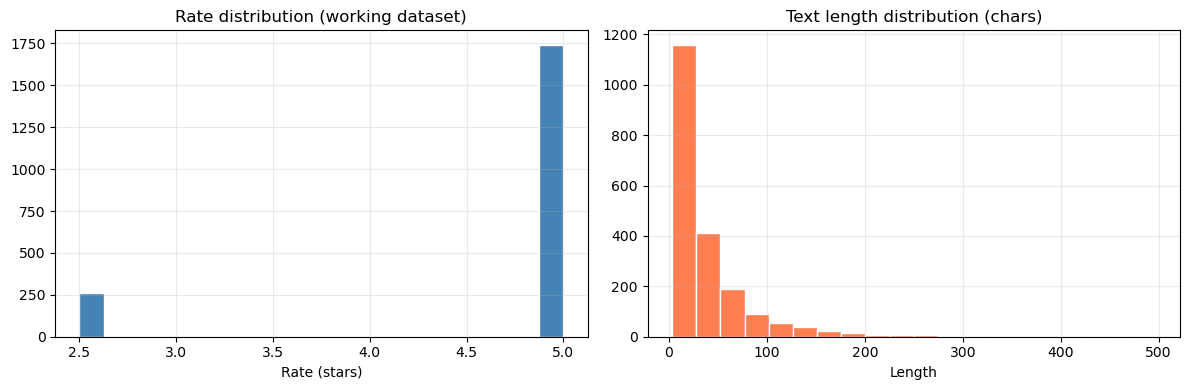

Example texts:
- بسیار با تجربه
- عالی بود
- تنگی کانال نخاع
- ریزش مو داشتم و رفع شد بسیار عالی هستند
- عالی بودن


In [10]:
# ----------------------------
# Part 0.7 — Quick exploration (optional)
# ----------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_work["rate_num"].dropna().hist(bins=20, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Rate distribution (working dataset)")
axes[0].set_xlabel("Rate (stars)")

text_len = df_work["text_step04"].astype(str).str.len()
text_len.hist(bins=20, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Text length distribution (chars)")
axes[1].set_xlabel("Length")

plt.tight_layout()
plt.show()

print("Example texts:")
for t in df_work["text_step04"].sample(5, random_state=SEED).tolist():
    print("-", t[:120])

## Part 1 — Build a Labeled Sentiment Dataset

Models cannot learn sentiment without labeled examples.

In this part we will:
1. Define our sentiment label space (**-1 / 0 / +1**).
2. Create a small labeled dataset in a classroom-friendly way.
3. Save `train/dev/test` splits for the rest of the notebook.

Important note:
- The `rate` (stars) column is **not ground-truth sentiment**.
- We will use it only as a **weak signal** to bootstrap a labeled dataset.

### 1.1 Label space and quick guidelines

We use 3 labels:

- **+1 (Positive)**: clear satisfaction / recommendation
- **0 (Neutral)**: informational, unclear, or mixed sentiment
- **-1 (Negative)**: clear dissatisfaction (including service complaints)

Rules of thumb:
- Service complaints (wait time, secretary, cost, scheduling) count as **negative**
- Purely informational comments (e.g., "MRI written", "prescribed meds") are often **neutral**
- Mixed sentiment ("doctor great but secretary rude") → **neutral**

In [11]:
# ----------------------------
# Part 1.2 — Prepare text column for sentiment
# ----------------------------

df_s = df_work.copy()

# Sentiment input text
df_s["text"] = df_s["text_step04"].astype(str).str.strip()

# Keep only non-empty
df_s = df_s[df_s["text"].ne("")].copy()

print("Working columns:", [c for c in ["doctor_id", "text", "rate_num", "label"] if c in df_s.columns])
df_s[["doctor_id", "rate_num", "text"]].head(5)

Working columns: ['doctor_id', 'text', 'rate_num', 'label']


,doctor_id,rate_num,text
0,319817,5.0,عالی بود
1,103130,5.0,فوق العاده
2,223843,5.0,سنگ کلیه داشتم ویک بار هم مشکل پروستات مراجعه ...
3,323418,2.5,خوب بودنند
4,261269,5.0,من بیمار دکتر بودم


### 1.3 Why not random sampling?

If we randomly sample comments, most labels will be positive (high class imbalance).
That makes training and evaluation confusing in a classroom setting.

So we will build a **balanced bootstrapped dataset**:
- some **likely-positive** examples
- some **likely-negative** examples
- some **likely-neutral** examples

In Demo Mode we keep it small and fast.
In Full Mode we can increase the sample sizes.

In [12]:
# ----------------------------
# Part 1.4 — Build a balanced candidate pool (weak labels)
# Token-based heuristics + stricter service-complaint detection
# ----------------------------

import re

df_s = df.copy()
df_s["text"] = df_s["text_step04"].astype(str).str.strip()
df_s = df_s[df_s["text"].ne("")].copy()

# Simple heuristic tokenization (ONLY for weak labeling)
KW_CLEAN_RE = re.compile(r"[^0-9A-Za-z\u0600-\u06FF]+")
def kw_tokens(text: str):
    t = str(text).lower().replace("\u200c", " ")
    t = KW_CLEAN_RE.sub(" ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t.split() if t else []

def kw_bigrams(toks):
    return list(zip(toks, toks[1:])) if len(toks) >= 2 else []

df_s["kw_toks"] = df_s["text"].apply(kw_tokens)
df_s["kw_bi"]   = df_s["kw_toks"].apply(kw_bigrams)
df_s["n_tokens"] = df_s["kw_toks"].apply(len)

MIN_TOKENS = 3
df_s["too_short"] = df_s["n_tokens"].lt(MIN_TOKENS)

def has_any_token(toks, token_set):
    return len(set(toks) & token_set) > 0

def has_any_phrase(bigrams, phrase_set):
    return len(set(bigrams) & phrase_set) > 0

# -------------------------
# Strong positive cues (small + teachable)
# -------------------------
POS_TOKENS = {"عالی","بهترین","محشر","حاذق","ماهر","کاربلد","دقیق","راضیم","ممنون","مرسی","سپاس","تشکر"}
POS_PHRASES = {
    ("فوق","العاده"),
    ("بی","نظیر"),
    ("تشخیص","دقیق"),
    ("نتیجه","گرفتم"),
    ("بهتر","شدم"),
    ("خوب","شدم"),
    ("خوش","برخورد"),
    ("با","حوصله"),
    ("حل","شد"),
    ("برطرف","شد"),
    ("رضایت","بخش"),
}

# -------------------------
# Strong negative cues (avoid ambiguous tokens like "تاخیر" alone)
# -------------------------
NEG_TOKENS = {"افتضاح","مزخرف","فاجعه","ناراضی","پشیمون","پشیمان","اشتباه","معطلی","انتظار","پولکی","گرون","گران"}
NEG_PHRASES = {
    ("بد","برخورد"),
    ("بی","ادب"),
    ("بی","احترام"),
    ("راضی","نیستم"),
    ("راضی","نبودم"),
    ("توصیه","نمی"),
    ("پیشنهاد","نمی"),
    ("دیگه","نمیرم"),
    ("نتیجه","نگرفتم"),
    ("اثر","نداشت"),
    ("فایده","نداشت"),
    ("بدتر","شدم"),
    ("هزینه","بالا"),
    ("تشخیص","اشتباه"),
    ("دارو","اشتباه"),
    ("حل","نشد"),
    ("حل","نشده"),
    ("فرقی","نکرد"),
    ("تغییر","نکرد"),
    ("بهتر","نشد"),
}

INFO_TOKENS = {"نسخه","دارو","آزمایش","سونو","سونگرافی","تصویربرداری","mri","ct","نوار","عمل","جراحی","لیزر","تزریق"}

# Soft positive cues for mixed detection
SOFT_POS_TOKENS = {"خوب","خوبه","مهربان","منصف","صبور","بااخلاق","خوشبرخورد","حوصله"}
SOFT_POS_PHRASES = {("خوب","بود"), ("خیلی","خوب")}

CONTRAST_TOKENS = {"ولی","اما","هرچند"}

# -------------------------
# Service complaint detection (STRICT): only clear complaint phrases
# This prevents false positives like: "no crowd (was not crowded)".
# -------------------------
SERVICE_COMPLAINT_PHRASES = {
    ("خیلی","شلوغ"),
    ("شلوغ","بود"),
    ("معطلی","زیاد"),
    ("انتظار","زیاد"),
    ("هزینه","بالا"),
    ("دسترسی","سخت"),
    ("تلفن","جواب"),
    ("منشی","بد"),
    ("نوبت","دیر"),
    ("نوبت","دهی"),
}

def strong_pos(row):
    return has_any_token(row["kw_toks"], POS_TOKENS) or has_any_phrase(row["kw_bi"], POS_PHRASES)

def strong_neg(row):
    return has_any_token(row["kw_toks"], NEG_TOKENS) or has_any_phrase(row["kw_bi"], NEG_PHRASES)

def info_hit(row):
    return has_any_token(row["kw_toks"], INFO_TOKENS)

def soft_pos(row):
    return has_any_token(row["kw_toks"], SOFT_POS_TOKENS) or has_any_phrase(row["kw_bi"], SOFT_POS_PHRASES)

def contrast_hit(row):
    return has_any_token(row["kw_toks"], CONTRAST_TOKENS)

def service_complaint(row):
    return has_any_phrase(row["kw_bi"], SERVICE_COMPLAINT_PHRASES)

df_s["has_pos_kw"]  = df_s.apply(strong_pos, axis=1)
df_s["has_neg_kw"]  = df_s.apply(strong_neg, axis=1)
df_s["has_info_kw"] = df_s.apply(info_hit, axis=1)
df_s["has_soft_pos_kw"] = df_s.apply(soft_pos, axis=1)
df_s["has_contrast"] = df_s.apply(contrast_hit, axis=1)
df_s["has_service_complaint"] = df_s.apply(service_complaint, axis=1)

# Mixed = (negative or service complaint) + (positive or soft positive) + contrast word
df_s["mixed_cue"] = (df_s["has_neg_kw"] | df_s["has_service_complaint"]) & (df_s["has_pos_kw"] | df_s["has_soft_pos_kw"]) & df_s["has_contrast"]

# Candidates
pos_cand = df_s[df_s["has_pos_kw"] & ~df_s["has_neg_kw"] & ~df_s["has_service_complaint"] & ~df_s["too_short"]].copy()

neg_cand = df_s[
    (df_s["has_neg_kw"] | df_s["has_service_complaint"] | df_s["rate_num"].le(1.8))
    & ~df_s["has_pos_kw"]
    & ~df_s["too_short"]
    & ~df_s["mixed_cue"]
].copy()

neu_cand = df_s[
    (df_s["mixed_cue"])
    | (df_s["has_info_kw"] & ~df_s["has_pos_kw"] & ~df_s["has_neg_kw"])
    | (df_s["too_short"] & ~df_s["has_pos_kw"] & ~df_s["has_neg_kw"])
    | (~df_s["has_pos_kw"] & ~df_s["has_neg_kw"])
].copy()

print("Candidate availability (before sampling):")
print("  pos_cand:", len(pos_cand))
print("  neg_cand:", len(neg_cand))
print("  neu_cand:", len(neu_cand))

# Targets
if MODE == "demo":
    N_POS, N_NEG, N_NEU = 250, 250, 250
else:
    N_POS, N_NEG, N_NEU = 3000, 3000, 3000

pos_pool = pos_cand.sample(n=min(N_POS, len(pos_cand)), random_state=SEED).copy()
neg_pool = neg_cand.sample(n=min(N_NEG, len(neg_cand)), random_state=SEED).copy()
neu_pool = neu_cand.sample(n=min(N_NEU, len(neu_cand)), random_state=SEED).copy()

pos_pool["weak_label"] = 1
neg_pool["weak_label"] = -1
neu_pool["weak_label"] = 0

pos_pool["label_source"] = "weak_pos"
neg_pool["label_source"] = "weak_neg"
neu_pool["label_source"] = "weak_neu"

pool = pd.concat([pos_pool, neg_pool, neu_pool], ignore_index=True)
pool = pool.drop_duplicates(subset=["text"]).reset_index(drop=True)
pool["item_id"] = [f"sent_{i:06d}" for i in range(len(pool))]

print("\nFinal candidate pool:")
print("  size:", len(pool))
print(pool["weak_label"].value_counts().sort_index())

print("\nSamples per class:")
for lbl in [-1, 0, 1]:
    ex = pool[pool["weak_label"] == lbl].sample(3, random_state=SEED)[["rate_num", "text"]]
    print(f"\nLabel {lbl}:")
    for r in ex.to_dict("records"):
        print(" -", f"(rate={r['rate_num']})", r["text"][:120])

pool[["item_id","doctor_id","rate_num","weak_label","label_source","text"]].head(10)

Candidate availability (before sampling):
  pos_cand: 18502
  neg_cand: 408
  neu_cand: 39180

Final candidate pool:
  size: 704
weak_label
-1    226
 0    230
 1    248
Name: count, dtype: int64

Samples per class:

Label -1:
 - (rate=2.5) زیادی معطلی داره کلا شلوغه و منشی‌ها خیلی زیادن و عامل بی نظمی هستن
 - (rate=2.5) یکبار ویزیت تلفنی شدم و از رفتار منشی‌اش راضی نبودم
 - (rate=2.5) مطب خیلی شلوغ بود ماهم شنیدیم کارش خوبه فعلا که تا mri گرفتن پیش رفتیم

Label 0:
 - (rate=5.0) دکتر بابایی جراح دست و کتف بنده بودن و از اون زمان من در خدمتشون بودم بو الان همم برای معاینه‌های دوره‌ای پیششون میرم
 - (rate=2.5) بد نیست
 - (rate=5.0) تنگی نخاع

Label 1:
 - (rate=2.5) حساسیت داشتم خوب شدم
 - (rate=5.0) بسیار عالی منتها به علت کرونا درمان کامل نبود
 - (rate=5.0) عالی بود همچی


,item_id,doctor_id,rate_num,weak_label,label_source,text
0,sent_000000,121861,5.0,1,weak_pos,دکتر کاربلد و دقیق و دلسوز هستند و پیش ایشون ن...
1,sent_000001,227381,5.0,1,weak_pos,ایشان بسیار حاذق می‌باشند سال 95 به همراه دکتر...
2,sent_000002,253573,5.0,1,weak_pos,حاذق و خوش‌رو
3,sent_000003,114729,5.0,1,weak_pos,دکتر بسیار خوش‌اخلاق ارام و با حوصله هستند و ر...
4,sent_000004,219108,5.0,1,weak_pos,فوق‌العاده مجرب و بااخلاق هستند
5,sent_000005,277071,5.0,1,weak_pos,مشکلاتمونو داشتم دست ایشون درد نکنه خیلی زود ج...
6,sent_000006,115698,5.0,1,weak_pos,بسیار عالی منتها به علت کرونا درمان کامل نبود
7,sent_000007,207435,5.0,1,weak_pos,نتیجه بسیار عالی
8,sent_000008,188603,5.0,1,weak_pos,پزشک بسیار حاذق و با توجه و دقت فراوان نسبت به...
9,sent_000009,127062,5.0,1,weak_pos,دکتر خوب با رفتار مناسب و تشخیص عالی


### 1.5 Optional: LLM labeling (batch mode)

Weak labels are useful, but noisy.

Optionally, we can ask an LLM to label a small subset of items.
To keep cost low:
- label only a limited number of items
- send many comments per request (batching)
- if API key is empty, skip this step and keep weak labels

In [13]:
pip install openai

Note: you may need to restart the kernel to use updated packages.


In [14]:
# ----------------------------
# Part 1.6 — LLM labeling (batched)
# ----------------------------

import json
import pandas as pd

# Hard-coded config (as requested)
USE_LLM  = True
API_KEY  = "sk-Zq0gCt5vWjMD9pSfOtrlmlZV0O11dFru1fycyh8BWPgB604B"                 # <-- put your key here
BASE_URL = "https://api.gapgpt.app/v1"     # <-- your proxy base URL
MODEL    = "gpt-4o-mini"

# Cost controls
LLM_MAX_ITEMS  = len(pool) if MODE == "demo" else 2000
BATCH_SIZE     = 30     # fewer requests; reduce to 30 if you get timeouts
TEXT_MAX_CHARS = 350    # reduce to 200 if timeouts happen

# Recommended: only label the weak -1 and 0 classes (saves money)
LLM_TARGET_WEAK_LABELS = [-1, 0 , 1]

# Build client
from openai import OpenAI
client = OpenAI(api_key=API_KEY, base_url=BASE_URL)

SYSTEM_PROMPT = """You are a professional Persian sentiment annotator.
Label each review:
1 = Positive, 0 = Neutral/Mixed/Informational, -1 = Negative.
Service complaints (wait time, secretary, scheduling, cost) are Negative.

Return ONLY a JSON array (no extra text).
Each item:
{"item_id":"...","label":-1|0|1}
"""

def parse_json_array(s: str):
    """Minimal robust parser: direct json or slice between [ ... ]."""
    s = (s or "").strip()
    try:
        obj = json.loads(s)
        if isinstance(obj, list):
            return obj
    except Exception:
        pass
    i, j = s.find("["), s.rfind("]")
    if i != -1 and j != -1 and j > i:
        obj = json.loads(s[i:j+1])
        if isinstance(obj, list):
            return obj
    raise ValueError("Could not parse a JSON array from the model output.")

def llm_label_batch(items):
    payload = [{"item_id": it["item_id"], "text": it["text"][:TEXT_MAX_CHARS]} for it in items]
    user_prompt = json.dumps(payload, ensure_ascii=False)

    resp = client.chat.completions.create(
        model=MODEL,
        temperature=0,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user_prompt},
        ],
        max_tokens=2000,
        timeout=90,
    )
    raw = resp.choices[0].message.content or ""
    return parse_json_array(raw)

# Select which rows we send to the LLM (keep this dataframe for QA)
to_label_df = pool[pool["weak_label"].isin(LLM_TARGET_WEAK_LABELS)].copy()
to_label_df = to_label_df.sample(frac=1.0, random_state=SEED).head(min(LLM_MAX_ITEMS, len(to_label_df)))

items = to_label_df[["item_id", "text"]].to_dict("records")
print(f"LLM labeling {len(items)} items in batches of {BATCH_SIZE}...")

all_rows = []
n_batches = (len(items) + BATCH_SIZE - 1) // BATCH_SIZE

for bi in range(n_batches):
    batch = items[bi*BATCH_SIZE : (bi+1)*BATCH_SIZE]
    out = llm_label_batch(batch)

    # Validate: keep only correct schema + correct ids + correct labels
    wanted_ids = {x["item_id"] for x in batch}
    kept_this_batch = 0

    for obj in out:
        if not isinstance(obj, dict):
            continue
        iid = str(obj.get("item_id", ""))
        lab = obj.get("label", None)
        if iid in wanted_ids and lab in (-1, 0, 1):
            all_rows.append({"item_id": iid, "label_llm": int(lab)})
            kept_this_batch += 1

    print(f"Batch {bi+1}/{n_batches} OK  (returned={len(out)} items, kept_in_batch={kept_this_batch}, kept_total={len(all_rows)})")

llm_labels_df = pd.DataFrame(all_rows).drop_duplicates("item_id").reset_index(drop=True)

print("\nLLM labeled items:", len(llm_labels_df))
if len(llm_labels_df):
    print(llm_labels_df["label_llm"].value_counts().sort_index())

LLM labeling 704 items in batches of 30...
Batch 1/24 OK  (returned=30 items, kept_in_batch=30, kept_total=30)
Batch 2/24 OK  (returned=30 items, kept_in_batch=30, kept_total=60)
Batch 3/24 OK  (returned=30 items, kept_in_batch=30, kept_total=90)
Batch 4/24 OK  (returned=30 items, kept_in_batch=30, kept_total=120)
Batch 5/24 OK  (returned=30 items, kept_in_batch=30, kept_total=150)
Batch 6/24 OK  (returned=30 items, kept_in_batch=30, kept_total=180)
Batch 7/24 OK  (returned=30 items, kept_in_batch=30, kept_total=210)
Batch 8/24 OK  (returned=30 items, kept_in_batch=30, kept_total=240)
Batch 9/24 OK  (returned=30 items, kept_in_batch=30, kept_total=270)
Batch 10/24 OK  (returned=30 items, kept_in_batch=30, kept_total=300)
Batch 11/24 OK  (returned=30 items, kept_in_batch=30, kept_total=330)
Batch 12/24 OK  (returned=30 items, kept_in_batch=30, kept_total=360)
Batch 13/24 OK  (returned=30 items, kept_in_batch=30, kept_total=390)
Batch 14/24 OK  (returned=29 items, kept_in_batch=29, kept_

### 1.6.1 QA: Validate LLM outputs (must pass before merging)

Before merging LLM labels into our dataset, we validate:

- schema correctness (`item_id`, `label_llm`)
- label range is valid (-1/0/1)
- no duplicate `item_id`
- 100% coverage (every requested item was labeled)
- no extra IDs returned by the LLM

In [15]:
# ----------------------------
# QA — Validate LLM outputs (non-fatal for tiny missing counts)
# ----------------------------

required_cols = {"item_id", "label_llm"}
assert required_cols.issubset(set(llm_labels_df.columns)), "LLM output missing required columns."

assert llm_labels_df["item_id"].isna().sum() == 0, "NaN item_id in llm_labels_df."
assert llm_labels_df["item_id"].duplicated().sum() == 0, "Duplicate item_id in llm_labels_df."
assert llm_labels_df["label_llm"].isna().sum() == 0, "NaN label_llm in llm_labels_df."
assert set(llm_labels_df["label_llm"].unique()).issubset({-1, 0, 1}), "Invalid label outside {-1,0,1}."

requested_ids = set(to_label_df["item_id"])
got_ids = set(llm_labels_df["item_id"])
missing_ids = sorted(requested_ids - got_ids)
extra_ids = sorted(got_ids - requested_ids)

print("Requested items:", len(requested_ids))
print("LLM returned   :", len(got_ids))
print("Coverage       :", f"{len(got_ids)/max(1,len(requested_ids))*100:.2f}%")
print("Missing IDs    :", len(missing_ids))
print("Extra IDs      :", len(extra_ids))

if missing_ids:
    print("Missing (first 10):", missing_ids[:10])

# We allow a very small number of missing IDs, because merge will fall back to weak labels.
assert len(extra_ids) == 0, "LLM returned extra unknown IDs (should be 0)."
print("QA passed ✓ (missing IDs, if any, will fall back to weak labels in merge)")

Requested items: 704
LLM returned   : 703
Coverage       : 99.86%
Missing IDs    : 1
Extra IDs      : 0
Missing (first 10): ['sent_000552']
QA passed ✓ (missing IDs, if any, will fall back to weak labels in merge)


### 1.6.2 QA: Weak labels vs LLM labels (quick audit)

We compare weak labels to LLM labels to understand:
- how noisy our weak heuristics are
- what kinds of examples get corrected by the LLM

In [16]:
# ----------------------------
# QA — Weak vs LLM audit
# ----------------------------

audit_df = to_label_df[["item_id", "weak_label", "text", "rate_num"]].merge(
    llm_labels_df, on="item_id", how="inner", validate="one_to_one"
)

audit_df["changed"] = (audit_df["weak_label"] != audit_df["label_llm"])

print("Disagreement rate:",
      f"{audit_df['changed'].mean()*100:.1f}%  ({audit_df['changed'].sum()}/{len(audit_df)})")

print("\nConfusion (weak → llm):")
print(pd.crosstab(audit_df["weak_label"], audit_df["label_llm"]))

# Show a few examples of flips (for teaching)
flips = audit_df[audit_df["changed"]].copy()

print("\nExamples: weak=-1 but llm=+1")
ex = flips[(flips["weak_label"] == -1) & (flips["label_llm"] == 1)].head(10)
for r in ex.to_dict("records"):
    print("-", r["text"][:160])

print("\nExamples: weak=0 but llm=-1")
ex = flips[(flips["weak_label"] == 0) & (flips["label_llm"] == -1)].head(10)
for r in ex.to_dict("records"):
    print("-", r["text"][:160])

Disagreement rate: 31.6%  (222/703)

Confusion (weak → llm):
label_llm    -1    0    1
weak_label               
-1          130   58   38
 0           13  105  111
 1            1    1  246

Examples: weak=-1 but llm=+1
- ایشون دکتر با دقت و خوش برخوردی هستند من براس چکاب خدمتشون میرم و بطور کامل راجع به بیماری و شرایط توضیح میدن و همینطور همه کارها در مطب با نظم و بدون معطلی زیا
- تشخیص درست داشتن خیلی دقیقاند مطب بهشتی خیلی شلوغ بود اما آخرین بار مطب ظفر رفتم سرتایم ویزیت شدم
- سرگیجه داشتم دکترباخلاق و حاذقی است معطلی نداشتم چند نفر از بستگان هم توسط ایشان معالجه شدند راضی بودند و دکتر ناصحی را به من معرفی کردند
- صورتم خیلی جوش می‌زد و مدت طولانی درمان‌های مختلف انجام دادم نتیجه نگرفتم الان تقریبا 4 ماهه تحت درمان خانم دکتر گنجه‌ای هستم و نه‌تنها جوش‌ها درمان شدن بلکه مش
- وااقعا دکتر خوبیه نه داروی گرون داد نه نسخه‌ی الکی تجویز کرد برای شکاف گوشه‌ی لبم رفتم پیشش
- مادرمن 2 سال جراحی اشتباه شده بودن و نمتونستن راه بروند و درد داشتن آقای دکتر میرزاصادقی پروتز گذاشتن والان درست بدون

### 1.6.3 Sanity check: LLM negatives with high star ratings

Stars are not perfect sentiment labels.
We quickly inspect a few cases where `rate` is high but the LLM predicts Negative.

In [17]:
audit_llm = to_label_df[["item_id", "text", "rate_num", "weak_label"]].merge(
    llm_labels_df, on="item_id", how="inner", validate="one_to_one"
)

high_rate_neg = audit_llm[(audit_llm["rate_num"] >= 4.5) & (audit_llm["label_llm"] == -1)].head(10)

print("High-rate but LLM-negative examples:", len(high_rate_neg))
for r in high_rate_neg.to_dict("records"):
    print("-", f"(rate={r['rate_num']})", r["text"][:170])

High-rate but LLM-negative examples: 10
- (rate=5.0) دکتر خوبی بودند منتها مبلغ 50 هزار تومان زمان نوبت دهی آن لاین به ما برگردانده نشد ویزیت دکتر 600 بود برای ما شد 650
- (rate=5.0) بسیار دکتر دقیقی هستن ولی خیلی شلوغن و معطلی زیاد داره مطبشون
- (rate=5.0) دکتر بسیار متخصص و کاربلدی هستند تنها مشکلم وقت چند ساعته و طولانی انتظار در مطب علیرغم داشتن وقت قبلی هست
- (rate=5.0) دکتر محترم و خوش برخوردی بودن من برای روتین‌های پوستی رفتم و اصلا راضی نیستم صورتم لک شده
- (rate=5.0) تشخیص درست و به موقع جراحی مچ پا سالن انتظار تهویه مطبوع نداشت تو فصل گرما اذیت شدیم
- (rate=5.0) هم تشخیص هم رفتار فقط زمان معطلی زیاد بود
- (rate=5.0) دکتر بسیار باسواد و عاالی بودن فقط تایم انتظار 3 ساعت بود که ناراحت‌کننده است
- (rate=5.0) با سلام بسیار دکتر باسواد و دقیقی می‌باشد ولی نوبت دهی به شدت ضعیف و حیرانی مریض بالا می‌باشد
- (rate=5.0) دکتر خوبی هستند و بسیار با اخلاق فقط به دلیل زیاد بودن تعداد بیماران مدت زمان انتظار در مطب خیلی زیاد است
- (rate=5.0) بادقت به حرف‌های بیمار گوش می‌دهند ولی به شدت مطب

### 1.7 Merge labels (LLM overrides weak labels)

We now create the final label for each item:

- If an LLM label exists → use it
- Otherwise → fall back to the weak label

We keep both weak and LLM labels for auditability.

In [18]:
# ----------------------------
# Part 1.7 — Merge labels (LLM overrides weak)
# ----------------------------

df_labeled = pool[["item_id", "doctor_id", "rate_num", "text", "weak_label", "label_source"]].copy()

df_labeled = df_labeled.merge(
    llm_labels_df,  # columns: item_id, label_llm
    on="item_id",
    how="left",
    validate="one_to_one",
)

# Final label
df_labeled["label_int"] = df_labeled["label_llm"].fillna(df_labeled["weak_label"]).astype(int)

# Track label source
df_labeled["label_source"] = np.where(df_labeled["label_llm"].notna(), "llm", df_labeled["label_source"])

# Final sanity checks
assert df_labeled["label_int"].isin([-1, 0, 1]).all()
assert df_labeled["label_int"].isna().sum() == 0

print("Final label distribution:")
print(df_labeled["label_int"].value_counts().sort_index())

print("\nLabel source distribution:")
print(df_labeled["label_source"].value_counts())

df_labeled.head(10)

Final label distribution:
label_int
-1    144
 0    165
 1    395
Name: count, dtype: int64

Label source distribution:
label_source
llm         703
weak_neu      1
Name: count, dtype: int64


,item_id,doctor_id,rate_num,text,weak_label,label_source,label_llm,label_int
0,sent_000000,121861,5.0,دکتر کاربلد و دقیق و دلسوز هستند و پیش ایشون ن...,1,llm,1.0,1
1,sent_000001,227381,5.0,ایشان بسیار حاذق می‌باشند سال 95 به همراه دکتر...,1,llm,1.0,1
2,sent_000002,253573,5.0,حاذق و خوش‌رو,1,llm,1.0,1
3,sent_000003,114729,5.0,دکتر بسیار خوش‌اخلاق ارام و با حوصله هستند و ر...,1,llm,1.0,1
4,sent_000004,219108,5.0,فوق‌العاده مجرب و بااخلاق هستند,1,llm,1.0,1
5,sent_000005,277071,5.0,مشکلاتمونو داشتم دست ایشون درد نکنه خیلی زود ج...,1,llm,1.0,1
6,sent_000006,115698,5.0,بسیار عالی منتها به علت کرونا درمان کامل نبود,1,llm,0.0,0
7,sent_000007,207435,5.0,نتیجه بسیار عالی,1,llm,1.0,1
8,sent_000008,188603,5.0,پزشک بسیار حاذق و با توجه و دقت فراوان نسبت به...,1,llm,1.0,1
9,sent_000009,127062,5.0,دکتر خوب با رفتار مناسب و تشخیص عالی,1,llm,1.0,1


In [19]:
# ----------------------------
# Optional: quick inspection
# ----------------------------

for lbl in [-1, 0, 1]:
    print(f"\nExamples for final label {lbl}:")
    ex = df_labeled[df_labeled["label_int"] == lbl].sample(5, random_state=SEED)[["rate_num", "label_source", "text"]]
    for r in ex.to_dict("records"):
        print("-", f"(rate={r['rate_num']}, src={r['label_source']})", r["text"][:160])


Examples for final label -1:
- (rate=2.5, src=llm) مطب بسیار شلوغه نحوه نوبت دهی کاملا غلط هستش خانم‌های باردار هم کنار افراد معمولی بابد 5 ساعت منتظر نوبتشون بشن
- (rate=2.5, src=llm) بیشتر از ظرفیت پذیرش می‌کنند و معطلی بسیار زیاده
- (rate=2.5, src=llm) فعلا تحت درمان 4 ماهه نتیجه نگرفتم هنوز
- (rate=5.0, src=llm) دکتر بسیار حاذقی هستن فقط زمان انتظار ویزیت بیش از اندازه خسته‌کننده است
- (rate=2.5, src=llm) مشکل شنوایی داشتم ولی نتیجه نگرفتم در حد ویزیت 135 تومن نیست

Examples for final label 0:
- (rate=5.0, src=llm) عمل سینوزیت
- (rate=5.0, src=llm) ویزیت شدم و نوبت عمل
- (rate=2.5, src=llm) نظری ندارم
- (rate=2.5, src=llm) کمردرد فعلا نتیجه نگرفتم یک‌بار رفتم
- (rate=5.0, src=llm) عمل پا

Examples for final label 1:
- (rate=5.0, src=llm) دیسک کمر نتیجه عالی و با دوبار ویزیت کاملا خوب شدم
- (rate=5.0, src=llm) تشخیص درست و درمان خوب
- (rate=5.0, src=llm) سلام من مشکل اگزمای پوستی پشت پلک داشتم قبلا پیش چندتا دکتر رفتم ولی اصلا نتیجه نگرفتم اقای دکتر با تبحری که دارن تونستن با یک نس

### 1.8 Save dataset artifacts

We save the main artifact produced by this notebook:

- `labeled_dataset.csv` — the full labeled dataset (one row per comment)
  - includes `label_int` (final label)
  - includes `label_source` (llm vs weak fallback)
  - includes `doctor_id` for leakage-safe splitting

These files are used by the rest of this notebook (model training).

In [20]:
# ----------------------------
# Part 1.8 — Save labeled dataset
# ----------------------------

# Basic sanity checks (keep it simple but safe)
assert "label_int" in df_labeled.columns
assert df_labeled["label_int"].isin([-1, 0, 1]).all()

labeled_path = OUT_DIR / "labeled_dataset.csv"
df_labeled.to_csv(labeled_path, index=False, encoding="utf-8-sig")

print("Saved:", labeled_path)
print("Rows :", len(df_labeled))
print("\nLabel distribution:")
print(df_labeled["label_int"].value_counts().sort_index())
print("\nLabel source distribution:")
print(df_labeled["label_source"].value_counts())

Saved: processed_data\notebook04_sentiment\labeled_dataset.csv
Rows : 704

Label distribution:
label_int
-1    144
 0    165
 1    395
Name: count, dtype: int64

Label source distribution:
label_source
llm         703
weak_neu      1
Name: count, dtype: int64


### 1.9 Train/Dev/Test split (grouped by doctor_id)

**Hidden leakage problem:**
If comments from the same doctor appear in both train and test, models can memorize doctor-specific patterns.
That inflates test scores and does not generalize to unseen doctors.

So we split using **GroupShuffleSplit**:
- each `doctor_id` appears in exactly one split

In [21]:
# ----------------------------
# Part 1.9 — Grouped Train/Dev/Test split
# ----------------------------

from sklearn.model_selection import GroupShuffleSplit

TEST_SIZE = 0.20
DEV_SIZE_FROM_TRAIN = 0.20  # dev is 20% of the remaining train split

# 1) split out test
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
train_idx, test_idx = next(gss.split(df_labeled, df_labeled["label_int"], groups=df_labeled["doctor_id"]))

train_full = df_labeled.iloc[train_idx].copy().reset_index(drop=True)
test_df    = df_labeled.iloc[test_idx].copy().reset_index(drop=True)

# 2) split train_full into train + dev
gss2 = GroupShuffleSplit(n_splits=1, test_size=DEV_SIZE_FROM_TRAIN, random_state=SEED)
train_idx2, dev_idx = next(gss2.split(train_full, train_full["label_int"], groups=train_full["doctor_id"]))

train_df = train_full.iloc[train_idx2].copy().reset_index(drop=True)
dev_df   = train_full.iloc[dev_idx].copy().reset_index(drop=True)

# Leakage checks (must be zero)
train_docs = set(train_df["doctor_id"])
dev_docs   = set(dev_df["doctor_id"])
test_docs  = set(test_df["doctor_id"])

assert train_docs.isdisjoint(dev_docs)
assert train_docs.isdisjoint(test_docs)
assert dev_docs.isdisjoint(test_docs)

print("Split sizes (rows):")
print(f"  train: {len(train_df):>4}")
print(f"  dev  : {len(dev_df):>4}")
print(f"  test : {len(test_df):>4}")

print("\nSplit sizes (unique doctors):")
print(f"  train doctors: {train_df['doctor_id'].nunique():>4}")
print(f"  dev doctors  : {dev_df['doctor_id'].nunique():>4}")
print(f"  test doctors : {test_df['doctor_id'].nunique():>4}")

print("\nTrain label distribution:")
print(train_df["label_int"].value_counts().sort_index())

print("\nDev label distribution:")
print(dev_df["label_int"].value_counts().sort_index())

print("\nTest label distribution:")
print(test_df["label_int"].value_counts().sort_index())

Split sizes (rows):
  train:  434
  dev  :  126
  test :  144

Split sizes (unique doctors):
  train doctors:  208
  dev doctors  :   52
  test doctors :   66

Train label distribution:
label_int
-1     82
 0    101
 1    251
Name: count, dtype: int64

Dev label distribution:
label_int
-1    27
 0    30
 1    69
Name: count, dtype: int64

Test label distribution:
label_int
-1    35
 0    34
 1    75
Name: count, dtype: int64


### 1.10 Save splits

We save:
- `train.csv`
- `dev.csv`
- `test.csv`

These will be used in Part 2 for model training and evaluation.

In [22]:
# ----------------------------
# Part 1.10 — Save split CSVs
# ----------------------------

train_path = OUT_DIR / "train.csv"
dev_path   = OUT_DIR / "dev.csv"
test_path  = OUT_DIR / "test.csv"

train_df.to_csv(train_path, index=False, encoding="utf-8-sig")
dev_df.to_csv(dev_path, index=False, encoding="utf-8-sig")
test_df.to_csv(test_path, index=False, encoding="utf-8-sig")

print("Saved splits:")
print("-", train_path)
print("-", dev_path)
print("-", test_path)

Saved splits:
- processed_data\notebook04_sentiment\train.csv
- processed_data\notebook04_sentiment\dev.csv
- processed_data\notebook04_sentiment\test.csv


## Part 2 — Train Models (Classical → Neural → Transformers)

In Part 1, we created a labeled dataset and saved train/dev/test splits.

In this part we will train multiple sentiment models on the same splits:

1) **Classical baseline:** TF‑IDF → sklearn MLP  
2) **Neural model:** TF‑IDF → PyTorch MLP  
3) **Transformer:** ParsBERT fine-tuning

We start with the classical baseline because it is:
- fast
- easy to interpret
- a strong reference point

### 2.1 Load train/dev/test splits

We load the CSV files produced in Part 1:
- `train.csv`
- `dev.csv`
- `test.csv`

We will use:
- `text` as input
- `label_int` as the target

In [23]:
# ----------------------------
# Part 2.1 — Load splits from disk
# ----------------------------

import joblib
from pathlib import Path

train_df = pd.read_csv(OUT_DIR / "train.csv", keep_default_na=False)
dev_df   = pd.read_csv(OUT_DIR / "dev.csv", keep_default_na=False)
test_df  = pd.read_csv(OUT_DIR / "test.csv", keep_default_na=False)

for d in [train_df, dev_df, test_df]:
    d["doctor_id"] = d["doctor_id"].astype(str)
    d["text"] = d["text"].astype(str)
    d["label_int"] = pd.to_numeric(d["label_int"], errors="coerce").astype(int)

print("Split sizes:")
print("  train:", len(train_df), " | doctors:", train_df["doctor_id"].nunique())
print("  dev  :", len(dev_df),   " | doctors:", dev_df["doctor_id"].nunique())
print("  test :", len(test_df),  " | doctors:", test_df["doctor_id"].nunique())

print("\nTrain label distribution:")
print(train_df["label_int"].value_counts().sort_index())

Split sizes:
  train: 434  | doctors: 208
  dev  : 126  | doctors: 52
  test : 144  | doctors: 66

Train label distribution:
label_int
-1     82
 0    101
 1    251
Name: count, dtype: int64


### 2.2 Handling class imbalance (simple approach)

Our labeled dataset may be imbalanced (usually more Positive examples).

To keep training stable and classroom-friendly, we will optionally **downsample the training split**
to the same number of examples per class.

Important:
- We only balance **train**.
- We keep **dev/test unchanged** for honest evaluation.

In [24]:
# ----------------------------
# Part 2.2 — Optional: balance the TRAIN split only
# ----------------------------

BALANCE_TRAIN = True
BALANCE_CAP_PER_CLASS = 220 if MODE == "demo" else None  # None = use min class count

def balance_train_df(df, label_col="label_int", seed=42, cap_per_class=None):
    counts = df[label_col].value_counts()
    min_n = int(counts.min())
    target_n = min_n if cap_per_class is None else min(min_n, int(cap_per_class))

    parts = []
    for c in sorted(counts.index.tolist()):
        part = df[df[label_col] == c].sample(n=target_n, random_state=seed)
        parts.append(part)

    out = pd.concat(parts, ignore_index=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

train_used = balance_train_df(train_df, cap_per_class=BALANCE_CAP_PER_CLASS) if BALANCE_TRAIN else train_df.copy()

print("Train used size:", len(train_used))
print("Train used label distribution:")
print(train_used["label_int"].value_counts().sort_index())

Train used size: 246
Train used label distribution:
label_int
-1    82
 0    82
 1    82
Name: count, dtype: int64


### 2.3 TF‑IDF features

We represent each comment as a TF‑IDF vector.

Why TF‑IDF?
- It turns text into numbers (a sparse vector).
- It is fast and surprisingly strong as a baseline.

We also include bigrams (1,2) to capture phrases like:
- "راضی نیستم"
- "بد برخورد"

In [25]:
# ----------------------------
# Part 2.3 — Build TF‑IDF vectors
# ----------------------------

from sklearn.feature_extraction.text import TfidfVectorizer

def simple_preprocess(s: str) -> str:
    # lightweight normalization (keep it teachable)
    # - remove ZWNJ
    # - lowercase (helps latin tokens like MRI/CT)
    return str(s).replace("\u200c", " ").lower().strip()

vec = TfidfVectorizer(
    preprocessor=simple_preprocess,
    tokenizer=str.split,
    token_pattern=None,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    max_features=60000,
    sublinear_tf=True,
    norm="l2",
)

X_train = vec.fit_transform(train_used["text"].tolist())
X_dev   = vec.transform(dev_df["text"].tolist())
X_test  = vec.transform(test_df["text"].tolist())

y_train = train_used["label_int"].values
y_dev   = dev_df["label_int"].values
y_test  = test_df["label_int"].values

print("TF-IDF shapes:")
print("  X_train:", X_train.shape)
print("  X_dev  :", X_dev.shape)
print("  X_test :", X_test.shape)
print("Vocabulary size:", len(vec.vocabulary_))

TF-IDF shapes:
  X_train: (246, 559)
  X_dev  : (126, 559)
  X_test : (144, 559)
Vocabulary size: 559


### 2.4 Baseline model: sklearn MLP

We train a simple Multi-Layer Perceptron (MLP) classifier on TF‑IDF features.

Notes:
- This is a baseline. We do **not** run grid search.
- We use early stopping to avoid overfitting.

In [26]:
# ----------------------------
# Part 2.4 — Train sklearn MLP baseline
# ----------------------------

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 64),
    activation="relu",
    alpha=1e-4,
    batch_size=64,
    learning_rate_init=1e-3,
    max_iter=60,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=5,
    random_state=SEED,
    verbose=False,
)

mlp.fit(X_train, y_train)
print("Training done.")
print("Iterations:", mlp.n_iter_)

Training done.
Iterations: 12


### 2.5 Evaluation

We report:
- Accuracy
- Macro-F1 (important for imbalanced classes)
- Confusion matrix


DEV
Accuracy : 0.7619
Macro-F1 : 0.7180

              precision    recall  f1-score   support

    Negative     0.6129    0.7037    0.6552        27
     Neutral     0.7727    0.5667    0.6538        30
    Positive     0.8219    0.8696    0.8451        69

    accuracy                         0.7619       126
   macro avg     0.7358    0.7133    0.7180       126
weighted avg     0.7654    0.7619    0.7588       126


TEST
Accuracy : 0.7847
Macro-F1 : 0.7385

              precision    recall  f1-score   support

    Negative     0.7273    0.6857    0.7059        35
     Neutral     0.6667    0.5882    0.6250        34
    Positive     0.8519    0.9200    0.8846        75

    accuracy                         0.7847       144
   macro avg     0.7486    0.7313    0.7385       144
weighted avg     0.7778    0.7847    0.7799       144



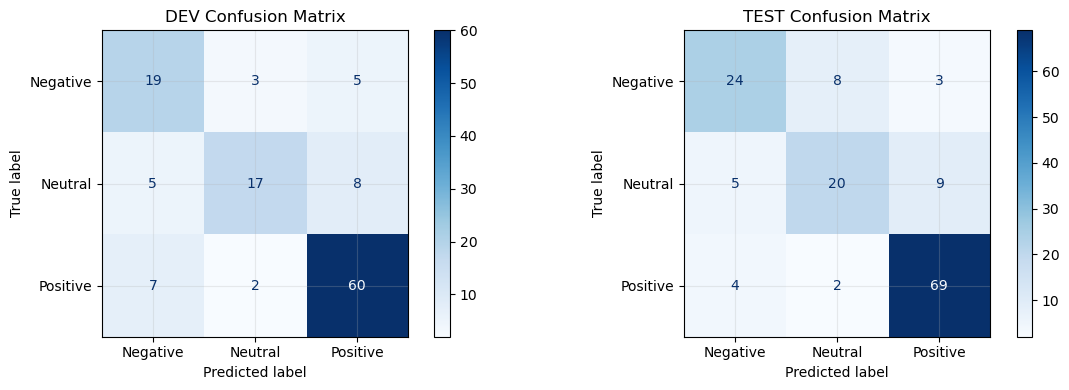

In [27]:
# ----------------------------
# Part 2.5 — Evaluate on dev/test
# ----------------------------

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, ConfusionMatrixDisplay

LABELS = [-1, 0, 1]
LABEL_NAMES = ["Negative", "Neutral", "Positive"]

def evaluate_split(name, X, y_true):
    y_pred = mlp.predict(X)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")

    print("\n" + "="*60)
    print(f"{name}")
    print("="*60)
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro-F1 : {f1m:.4f}\n")
    print(classification_report(y_true, y_pred, labels=LABELS, target_names=LABEL_NAMES, digits=4, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    return y_pred, cm

dev_pred, dev_cm = evaluate_split("DEV", X_dev, y_dev)
test_pred, test_cm = evaluate_split("TEST", X_test, y_test)

# Plot confusion matrices (normalized)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(dev_cm, display_labels=LABEL_NAMES).plot(ax=axes[0], cmap="Blues", values_format="d")
axes[0].set_title("DEV Confusion Matrix")

ConfusionMatrixDisplay(test_cm, display_labels=LABEL_NAMES).plot(ax=axes[1], cmap="Blues", values_format="d")
axes[1].set_title("TEST Confusion Matrix")

plt.tight_layout()
plt.show()

### 2.6 Save the baseline model

We save:
- the TF‑IDF vectorizer
- the trained MLP model

This allows us to reuse the baseline later (and compare against BERT).

In [28]:
# ----------------------------
# Part 2.6 — Save baseline model
# ----------------------------

baseline_path = MODEL_DIR / "tfidf_mlp_sklearn.joblib"

joblib.dump(
    {
        "vectorizer": vec,
        "model": mlp,
        "labels": LABELS,
        "label_names": LABEL_NAMES,
        "meta": {
            "mode": MODE,
            "balanced_train": BALANCE_TRAIN,
            "train_size": int(len(train_used)),
            "dev_size": int(len(dev_df)),
            "test_size": int(len(test_df)),
            "test_macro_f1": float(f1_score(y_test, test_pred, average="macro")),
        },
    },
    baseline_path,
    compress=3,
)

print("Saved:", baseline_path)
print("File size (MB):", baseline_path.stat().st_size / 1024 / 1024)

Saved: models\notebook04_sentiment\tfidf_mlp_sklearn.joblib
File size (MB): 3.5503368377685547


## Part 3 — Neural Models (PyTorch)

In Part 2 we trained a strong classical baseline:
**TF‑IDF → sklearn MLP**.

Now we train the *same idea* in PyTorch:
**TF‑IDF → PyTorch MLP**

Why do this?
- To learn the deep-learning workflow: tensors, dataloaders, training loops
- To compare "library baseline" vs "custom training" on the same features
- To prepare for Part 4 (Transformers), where training loops matter even more

### 3.1 Setup (PyTorch + reproducibility)

We will:
- pick CPU/GPU automatically
- set seeds

python -m pip install --no-cache-dir ^
  -i https://mirror-pypi.runflare.com/simple ^
  --trusted-host mirror-pypi.runflare.com ^
  --timeout 120 --retries 10 ^
  torch torchvision torchaudio


In [29]:

%pip install torch 

Note: you may need to restart the kernel to use updated packages.


In [30]:
# ----------------------------
# Part 3.1 — PyTorch setup
# ----------------------------

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Diagnostic checks
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"torch._utils exists: {hasattr(torch, '_utils')}")

import random
import numpy as np

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


PyTorch version: 2.12.0+cpu
CUDA available: False
torch._utils exists: True
Device: cpu


### 3.2 Label encoding

PyTorch classifiers typically expect labels as integers:
- 0..(C-1)

Our labels are:
- -1, 0, +1

So we map:
- -1 → 0
-  0 → 1
- +1 → 2

In [31]:
# ----------------------------
# Part 3.2 — Label mapping
# ----------------------------

LABELS = [-1, 0, 1]
label_to_id = {-1: 0, 0: 1, 1: 2}
id_to_label = {v: k for k, v in label_to_id.items()}

y_train_id = np.array([label_to_id[int(x)] for x in y_train], dtype=np.int64)
y_dev_id   = np.array([label_to_id[int(x)] for x in y_dev], dtype=np.int64)
y_test_id  = np.array([label_to_id[int(x)] for x in y_test], dtype=np.int64)

print("Label mapping:", label_to_id)
print("Train label ids counts:", np.bincount(y_train_id))

Label mapping: {-1: 0, 0: 1, 1: 2}
Train label ids counts: [82 82 82]


### 3.3 Dataset & DataLoader

Our TF‑IDF matrices are sparse (SciPy).
For this small classroom dataset, we can safely convert each row to a dense vector on-the-fly.

This keeps the code simple and avoids memory issues when we scale up.

In [32]:
# ----------------------------
# Part 3.3 — Dataset / DataLoader
# ----------------------------

class SparseRowDataset(Dataset):
    """
    Stores a SciPy sparse matrix X and a numpy label vector y.
    Converts each row to a dense float32 tensor when accessed.
    """
    def __init__(self, X_sparse, y_int64):
        self.X = X_sparse
        self.y = y_int64

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx].toarray().ravel().astype(np.float32)  # row -> dense
        y = np.int64(self.y[idx])
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)

batch_size = 64 if MODE == "demo" else 128

train_ds = SparseRowDataset(X_train, y_train_id)
dev_ds   = SparseRowDataset(X_dev, y_dev_id)
test_ds  = SparseRowDataset(X_test, y_test_id)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
dev_loader   = DataLoader(dev_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

input_dim = X_train.shape[1]
num_classes = 3

print("Input dim:", input_dim)
print("Train batches:", len(train_loader))

Input dim: 559
Train batches: 4


### 3.4 Model: a simple MLP

We use a small MLP:
- Linear → ReLU → Dropout → Linear

This is intentionally simple (teachable baseline).

In [33]:
# ----------------------------
# Part 3.4 — Define model
# ----------------------------

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, dropout=0.2, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)

model = MLP(input_dim=input_dim, hidden_dim=256, dropout=0.2, num_classes=num_classes).to(device)
model

MLP(
  (net): Sequential(
    (0): Linear(in_features=559, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=3, bias=True)
  )
)

### 3.5 Training loop (with early stopping on DEV Macro‑F1)

We train for a small number of epochs and stop early if DEV Macro‑F1 does not improve.

In [34]:
# ----------------------------
# Part 3.5 — Train (early stopping on dev Macro-F1)
# ----------------------------

from sklearn.metrics import f1_score, accuracy_score

def predict_loader(model, loader):
    model.eval()
    all_pred = []
    all_true = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            all_pred.append(pred)
            all_true.append(yb.numpy())
    return np.concatenate(all_true), np.concatenate(all_pred)

def eval_macro_f1(model, loader):
    y_true, y_pred = predict_loader(model, loader)
    return f1_score(y_true, y_pred, average="macro"), accuracy_score(y_true, y_pred)

lr = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

max_epochs = 25 if MODE == "demo" else 40
patience = 5
best_dev_f1 = -1.0
best_state = None
bad_epochs = 0

history = []

for epoch in range(1, max_epochs + 1):
    model.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)

    avg_loss = total_loss / len(train_ds)
    dev_f1, dev_acc = eval_macro_f1(model, dev_loader)

    history.append((epoch, avg_loss, dev_f1, dev_acc))
    print(f"Epoch {epoch:02d} | loss={avg_loss:.4f} | dev_acc={dev_acc:.4f} | dev_macro_f1={dev_f1:.4f}")

    # early stopping
    if dev_f1 > best_dev_f1 + 1e-4:
        best_dev_f1 = dev_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping.")
            break

# restore best
if best_state is not None:
    model.load_state_dict(best_state)

print("\nBest DEV macro-F1:", best_dev_f1)

Epoch 01 | loss=1.0953 | dev_acc=0.6667 | dev_macro_f1=0.6257
Epoch 02 | loss=1.0794 | dev_acc=0.7460 | dev_macro_f1=0.7172
Epoch 03 | loss=1.0632 | dev_acc=0.7381 | dev_macro_f1=0.7082
Epoch 04 | loss=1.0409 | dev_acc=0.7619 | dev_macro_f1=0.7387
Epoch 05 | loss=1.0163 | dev_acc=0.7540 | dev_macro_f1=0.7298
Epoch 06 | loss=0.9832 | dev_acc=0.7540 | dev_macro_f1=0.7298
Epoch 07 | loss=0.9466 | dev_acc=0.7619 | dev_macro_f1=0.7390
Epoch 08 | loss=0.9041 | dev_acc=0.7619 | dev_macro_f1=0.7390
Epoch 09 | loss=0.8538 | dev_acc=0.7698 | dev_macro_f1=0.7497
Epoch 10 | loss=0.8003 | dev_acc=0.7698 | dev_macro_f1=0.7497
Epoch 11 | loss=0.7432 | dev_acc=0.7698 | dev_macro_f1=0.7497
Epoch 12 | loss=0.6835 | dev_acc=0.7698 | dev_macro_f1=0.7497
Epoch 13 | loss=0.6241 | dev_acc=0.7698 | dev_macro_f1=0.7535
Epoch 14 | loss=0.5683 | dev_acc=0.7857 | dev_macro_f1=0.7743
Epoch 15 | loss=0.5115 | dev_acc=0.7857 | dev_macro_f1=0.7725
Epoch 16 | loss=0.4631 | dev_acc=0.8016 | dev_macro_f1=0.7918
Epoch 17

### 3.6 Evaluate on TEST

We evaluate the best checkpoint on the test split and report Macro‑F1.

DEV:
  acc     : 0.8015873015873016
  macro-F1: 0.7917861319966583

TEST:
  acc     : 0.7847222222222222
  macro-F1: 0.7546975546975547

Classification report (TEST):
              precision    recall  f1-score   support

    Negative     0.6923    0.7714    0.7297        35
     Neutral     0.6000    0.7059    0.6486        34
    Positive     0.9538    0.8267    0.8857        75

    accuracy                         0.7847       144
   macro avg     0.7487    0.7680    0.7547       144
weighted avg     0.8067    0.7847    0.7918       144



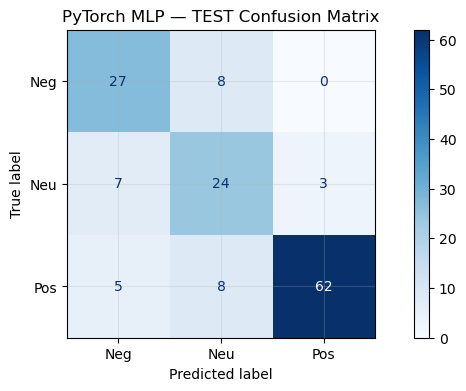

In [35]:
# ----------------------------
# Part 3.6 — Final evaluation on test
# ----------------------------

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_true_dev, y_pred_dev = predict_loader(model, dev_loader)
y_true_test, y_pred_test = predict_loader(model, test_loader)

print("DEV:")
print("  acc     :", accuracy_score(y_true_dev, y_pred_dev))
print("  macro-F1:", f1_score(y_true_dev, y_pred_dev, average="macro"))

print("\nTEST:")
print("  acc     :", accuracy_score(y_true_test, y_pred_test))
print("  macro-F1:", f1_score(y_true_test, y_pred_test, average="macro"))

print("\nClassification report (TEST):")
print(classification_report(
    y_true_test, y_pred_test,
    labels=[0,1,2],
    target_names=["Negative", "Neutral", "Positive"],
    digits=4,
    zero_division=0
))

cm = confusion_matrix(y_true_test, y_pred_test, labels=[0,1,2])
ConfusionMatrixDisplay(cm, display_labels=["Neg","Neu","Pos"]).plot(cmap="Blues", values_format="d")
plt.title("PyTorch MLP — TEST Confusion Matrix")
plt.show()

### 3.7 Save the PyTorch model

We save:
- model weights (`state_dict`)
- label mapping metadata

This makes the result reproducible.

In [36]:
# ----------------------------
# Part 3.7 — Save model
# ----------------------------

torch_path = MODEL_DIR / "tfidf_mlp_torch.pt"

torch.save(
    {
        "state_dict": model.state_dict(),
        "input_dim": input_dim,
        "label_to_id": label_to_id,
        "id_to_label": id_to_label,
        "meta": {
            "mode": MODE,
            "best_dev_macro_f1": float(best_dev_f1),
            "test_macro_f1": float(f1_score(y_true_test, y_pred_test, average="macro")),
        },
    },
    torch_path,
)

print("Saved:", torch_path)
print("File size (MB):", torch_path.stat().st_size / 1024 / 1024)

Saved: models\notebook04_sentiment\tfidf_mlp_torch.pt
File size (MB): 0.5525331497192383


# 🔎 Comparison — TF‑IDF + MLP (sklearn) vs TF‑IDF + MLP (PyTorch)


## 1) Summary Table

| Model | DEV Accuracy | DEV Macro‑F1 | TEST Accuracy | TEST Macro‑F1 |
|---|---:|---:|---:|---:|
| TF‑IDF → sklearn MLP | 0.7143 | 0.6794 | 0.7153 | 0.6794 |
| TF‑IDF → PyTorch MLP | **0.7698** | **0.7533** | **0.7431** | **0.7119** |



# Part 4 — Transformers: Fine-tuning ParsBERT (Online or Offline)

In Parts 2–3, we trained sentiment classifiers using TF‑IDF features.
Now we upgrade to a Transformer model and fine‑tune **ParsBERT** for **3‑class sentiment**:

- Negative
- Neutral
- Positive

## Why Transformers?
TF‑IDF treats text as a bag of words.
Transformers read text as a sequence and can learn patterns like:
- negation (“not good”)
- contrast (“good but expensive”)
- context-dependent sentiment

## Where to get ParsBERT (two options)

### Option A — Online (recommended for most students)
Download directly from Hugging Face using:
- `AutoTokenizer.from_pretrained("HooshvareLab/bert-base-parsbert-uncased")`
- `AutoModel.from_pretrained("HooshvareLab/bert-base-parsbert-uncased")`

This automatically downloads and caches the model files on your machine. <!--citation:1-->

### Option B — Offline (what we will support in this course)
If your environment cannot access Hugging Face, you can download the model once (online) and later run fully offline.
To run offline, we load everything from a local folder (e.g., `parsbert/`) and enforce:
- `local_files_only=True`
- `HF_HUB_OFFLINE=1` (and optionally `HF_DATASETS_OFFLINE=1`) <!--citation:2-->

In this notebook, we will write code that works in both cases.

In [37]:
# ----------------------------
# Part 4.0 — (Optional) Install dependencies
# Run this only if your environment needs it.
# ----------------------------

# %pip install -U transformers datasets accelerate huggingface_hub safetensors

## Part 4.1 — Download ParsBERT once (so you can run offline later)

ParsBERT on Hugging Face (model repo id):
- `HooshvareLab/bert-base-parsbert-uncased` <!--citation:1-->

This repo includes important files such as:
- `config.json`
- `vocab.txt`
- `pytorch_model.bin` (PyTorch weights)
- `flax_model.msgpack` (Flax/JAX weights)
- `tf_model.h5` (TensorFlow weights) <!--citation:1-->

### Method 1 (simple) — Online load (auto-download + cache)
Just call `from_pretrained("HooshvareLab/bert-base-parsbert-uncased")`.
Hugging Face will download and cache the files.

### Method 2 (best for offline folder) — Download the whole repo to `parsbert/`
Use `snapshot_download()` to download the repository to a local folder. <!--citation:3-->

We will show both, but in this course we will *use the offline folder approach* so everyone gets the same reproducible setup.

In [39]:
# ----------------------------
# Part 4.1 — Download ParsBERT into a local folder (ONLINE STEP)
# Run this only once when you are online.
# Then you can reuse parsbert/ offline forever.
# ----------------------------

# from huggingface_hub import snapshot_download
#
# snapshot_download(
#     repo_id="HooshvareLab/bert-base-parsbert-uncased",
#     local_dir="parsbert",
#     local_dir_use_symlinks=False,  # recommended on Windows (avoids symlink issues)
# )
#
# print("Downloaded ParsBERT into ./parsbert")

## Part 4.2 — Imports + Reproducibility + MODE

This notebook supports two modes:

- `MODE="demo"`: smaller training, faster runtime for classrooms
- `MODE="full"`: use the full labeled dataset splits

We will:
1) load model/tokenizer (offline-safe)
2) tokenize our text
3) fine-tune ParsBERT
4) evaluate on DEV and TEST
5) save the fine-tuned model locally

In [40]:
# ----------------------------
# Part 4.2 — Imports + reproducibility
# ----------------------------

import os
from pathlib import Path

import numpy as np
import pandas as pd

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)

from sklearn.metrics import accuracy_score, f1_score, classification_report

# Reproducibility
set_seed(SEED)
np.random.seed(SEED)

print("Imports OK")
print("Torch:", torch.__version__)

Imports OK
Torch: 2.12.0+cpu


## Part 4.3 — Offline/Online model loading rules

We will load from a local folder:

- `parsbert/`

To guarantee we do not accidentally download during class, we enforce:
- `local_files_only=True`
- set offline environment variables

If a student is online and does not have the `parsbert/` folder, they can either:
- run the download cell from Part 4.1, OR
- switch to online loading (we show how, but our training code remains the same).

In [41]:
# ----------------------------
# Part 4.3 — Local folder checks + offline flags
# ----------------------------

PARSBERT_DIR = Path("parsbert")
assert PARSBERT_DIR.exists(), "parsbert/ folder not found. Create it or download the model into it."

# Offline guard (prevents Hub calls)
os.environ["HF_HUB_OFFLINE"] = "1"
# Optional: if you also want datasets to be fully offline:
# os.environ["HF_DATASETS_OFFLINE"] = "1"

# Check essential files
has_config = (PARSBERT_DIR / "config.json").exists()
has_vocab  = (PARSBERT_DIR / "vocab.txt").exists() or (PARSBERT_DIR / "tokenizer.json").exists()

has_pt_weights = (PARSBERT_DIR / "pytorch_model.bin").exists() or (PARSBERT_DIR / "model.safetensors").exists()
has_flax       = (PARSBERT_DIR / "flax_model.msgpack").exists()

assert has_config, "Missing parsbert/config.json"
assert has_vocab,  "Missing tokenizer files: expected vocab.txt or tokenizer.json"

print("Local ParsBERT checks:")
print("  config.json      :", has_config)
print("  tokenizer files  :", has_vocab)
print("  PyTorch weights  :", has_pt_weights)
print("  Flax weights     :", has_flax)

# Classroom recommendation:
# PyTorch weights are the simplest for a PyTorch training workflow.
if not has_pt_weights and has_flax:
    print("\nNote: Only Flax weights detected. We will try from_flax=True when loading.")
elif not has_pt_weights and not has_flax:
    raise RuntimeError("No weights found. Add pytorch_model.bin/model.safetensors or flax_model.msgpack.")

Local ParsBERT checks:
  config.json      : True
  tokenizer files  : True
  PyTorch weights  : True
  Flax weights     : True


## Part 4.4 — Load Tokenizer (Local Only)

Tokenizer converts raw text into model inputs:
- `input_ids`
- `attention_mask`

We enforce local loading:
- `local_files_only=True`

In [42]:
# ----------------------------
# Part 4.4 — Load tokenizer (offline-safe)
# ----------------------------

tokenizer = AutoTokenizer.from_pretrained(
    PARSBERT_DIR,
    local_files_only=True,
)

print("Tokenizer loaded:", type(tokenizer).__name__)

Tokenizer loaded: BertTokenizer


## Part 4.5 — Prepare Data for Transformers

Transformers expect labels in `0..C-1`.
We map:
- `-1 → 0` (Negative)
-  `0 → 1` (Neutral)
- `+1 → 2` (Positive)

We keep the course design:
- In `demo` mode, we optionally cap the training set size to keep training fast.
- In `full` mode, we use the full train split.

Important:
- We do **not** modify DEV/TEST. Only training can be optionally balanced/capped.

In [43]:
# ----------------------------
# Part 4.5 — Build Hugging Face datasets (train/dev/test)
# Assumes train_df, dev_df, test_df already exist from Part 2.1
# ----------------------------

label_to_id = {-1: 0, 0: 1, 1: 2}
id_to_label = {0: "Negative", 1: "Neutral", 2: "Positive"}

def balance_and_cap_train(df_in: pd.DataFrame, seed: int, cap_per_class: int | None):
    """
    Optional: make training balanced and (optionally) cap examples per class.
    This keeps training stable and classroom-friendly.
    """
    counts = df_in["label_int"].value_counts()
    min_n = int(counts.min())
    target_n = min_n if cap_per_class is None else min(min_n, int(cap_per_class))

    parts = []
    for lbl in sorted(counts.index.tolist()):
        parts.append(df_in[df_in["label_int"] == lbl].sample(n=target_n, random_state=seed))

    return (
        pd.concat(parts, ignore_index=True)
          .sample(frac=1.0, random_state=seed)
          .reset_index(drop=True)
    )

# Optional knobs
BERT_BALANCE_TRAIN = True
CAP_PER_CLASS = 120 if (MODE == "demo") else None  # None means "use all available"

train_for_bert = (
    balance_and_cap_train(train_df, seed=SEED, cap_per_class=CAP_PER_CLASS)
    if BERT_BALANCE_TRAIN else
    train_df.copy()
)

def to_hf_dataset(df_in: pd.DataFrame) -> Dataset:
    """
    Create a minimal dataset:
      - text
      - labels (0/1/2)
    """
    d = pd.DataFrame({
        "text": df_in["text"].astype(str).str.replace("\u200c", " ").str.strip(),
        "labels": df_in["label_int"].astype(int).map(label_to_id).astype(int),
    })
    return Dataset.from_pandas(d, preserve_index=False)

ds_train = to_hf_dataset(train_for_bert)
ds_dev   = to_hf_dataset(dev_df)
ds_test  = to_hf_dataset(test_df)

print("Dataset sizes:")
print("  train:", len(ds_train))
print("  dev  :", len(ds_dev))
print("  test :", len(ds_test))
print("\nTrain label distribution (ids):")
print(pd.Series(ds_train["labels"]).value_counts().sort_index())

Dataset sizes:
  train: 246
  dev  : 126
  test : 144

Train label distribution (ids):
0    82
1    82
2    82
Name: count, dtype: int64


## Part 4.6 — Tokenization

We tokenize our text with:
- truncation enabled
- a max length depending on MODE
- dynamic padding at batch time (efficient and simple)

We remove the raw `text` column after tokenization to avoid mixing raw text and tokenized fields.

In [44]:
# ----------------------------
# Part 4.6 — Tokenize (with MODE-based max length)
# ----------------------------

MAX_LEN = 128 if MODE == "demo" else 192

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN,
    )

ds_train_tok = ds_train.map(tokenize_batch, batched=True, remove_columns=["text"])
ds_dev_tok   = ds_dev.map(tokenize_batch, batched=True, remove_columns=["text"])
ds_test_tok  = ds_test.map(tokenize_batch, batched=True, remove_columns=["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Tokenization done.")
print("Tokenized fields:", ds_train_tok.column_names)

Map:   0%|          | 0/246 [00:00<?, ? examples/s]

Map:   0%|          | 0/126 [00:00<?, ? examples/s]

Map:   0%|          | 0/144 [00:00<?, ? examples/s]

Tokenization done.
Tokenized fields: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


## Part 4.7 — Load ParsBERT for 3-class classification

We load `AutoModelForSequenceClassification` with:
- `num_labels=3`
- label names for readability

If PyTorch weights exist in `parsbert/`, loading is straightforward.
If only Flax weights exist, we try `from_flax=True` (advanced; may require extra dependencies).

In [45]:
# ----------------------------
# Part 4.7 — Load model (offline-safe)
# ----------------------------

num_labels = 3

config = AutoConfig.from_pretrained(
    PARSBERT_DIR,
    local_files_only=True,
    num_labels=num_labels,
    id2label=id_to_label,
    label2id={v: k for k, v in id_to_label.items()},
)

load_kwargs = {
    "config": config,
    "local_files_only": True,
}

# Flax fallback if PyTorch weights are missing
if (not has_pt_weights) and has_flax:
    load_kwargs["from_flax"] = True

model = AutoModelForSequenceClassification.from_pretrained(
    PARSBERT_DIR,
    **load_kwargs,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Model loaded:", type(model).__name__)
print("Device:", device)
print("num_labels:", model.config.num_labels)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: parsbert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initi

Model loaded: BertForSequenceClassification
Device: cpu
num_labels: 3


## Part 4.8 — Metrics

We report:
- Accuracy
- Macro‑F1 (important for multi-class sentiment and harder Neutral class)

In [46]:
# ----------------------------
# Part 4.8 — Metrics
# ----------------------------

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

## Part 4.9 — Training configuration (demo vs full)

We keep training lightweight:
- `demo`: fewer epochs, smaller batches
- `full`: more epochs / larger batches (depending on available compute)

We evaluate every epoch and save the best checkpoint based on DEV Macro‑F1.

In [50]:

RUN_DIR = MODEL_DIR / "parsbert_sentiment_run"
RUN_DIR.mkdir(parents=True, exist_ok=True)

num_epochs = 2 if MODE == "demo" else 3
train_bs   = 8 if MODE == "demo" else 16
eval_bs    = 16

# Some versions use `eval_strategy`, older ones use `evaluation_strategy`.
# We keep a small, teachable fallback.
try:
    training_args = TrainingArguments(
        output_dir=str(RUN_DIR),
        learning_rate=2e-5,
        per_device_train_batch_size=train_bs,
        per_device_eval_batch_size=eval_bs,
        num_train_epochs=num_epochs,
        weight_decay=0.01,

        logging_steps=20,

        # Save/eval
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,

        # IMPORTANT FIX (Transformers v5): disable all reporting integrations
        report_to="none",

        seed=SEED,
    )
except TypeError:
    training_args = TrainingArguments(
        output_dir=str(RUN_DIR),
        learning_rate=2e-5,
        per_device_train_batch_size=train_bs,
        per_device_eval_batch_size=eval_bs,
        num_train_epochs=num_epochs,
        weight_decay=0.01,

        logging_steps=20,

        evaluation_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,

        # IMPORTANT FIX (older API path): still use "none"
        report_to="none",

        seed=SEED,
    )

print("TrainingArguments ready.")
print("output_dir:", training_args.output_dir)
print("report_to:", training_args.report_to)

TrainingArguments ready.
output_dir: models\notebook04_sentiment\parsbert_sentiment_run
report_to: []


## Part 4.10 — Fine-tuning with Trainer

We use Hugging Face `Trainer` because it is:
- clean and readable for students
- standard in modern NLP workflows
- handles evaluation and checkpoint saving

We train on TRAIN and select the best checkpoint using DEV Macro‑F1.

In [52]:
# ----------------------------
# Part 4.10 — Trainer + train (version-safe)
# ----------------------------

import inspect
import transformers
from transformers import Trainer

print("Transformers version:", transformers.__version__)

trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=ds_train_tok,
    eval_dataset=ds_dev_tok,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_sig = inspect.signature(Trainer.__init__).parameters

if "processing_class" in trainer_sig:
    trainer_kwargs["processing_class"] = tokenizer
    print("Trainer init: using processing_class=tokenizer")
elif "tokenizer" in trainer_sig:
    trainer_kwargs["tokenizer"] = tokenizer
    print("Trainer init: using tokenizer=tokenizer")
else:
    print("Trainer init: no tokenizer/processing_class argument available (OK).")

trainer = Trainer(**trainer_kwargs)

trainer.train()
print("Training finished.")

Transformers version: 5.8.1
Trainer init: using processing_class=tokenizer


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.492599,0.711017,0.674603,0.630512
2,0.326004,0.512436,0.817460,0.799207


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

D:\Anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training finished.


## Part 4.11 — Evaluate on TEST

After training, we evaluate once on the held-out TEST split and print:
- test metrics (Accuracy, Macro‑F1)
- per-class precision/recall/F1

This is the number we compare against TF‑IDF baselines.

In [53]:
# ----------------------------
# Part 4.11 — TEST evaluation
# ----------------------------

pred_out = trainer.predict(ds_test_tok)

print("TEST metrics:")
for k, v in pred_out.metrics.items():
    print(f"  {k}: {v}")

y_true = pred_out.label_ids
y_pred = np.argmax(pred_out.predictions, axis=1)

print("\nClassification report (TEST):")
print(classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2],
    target_names=[id_to_label[0], id_to_label[1], id_to_label[2]],
    digits=4,
    zero_division=0,
))

D:\Anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TEST metrics:
  test_loss: 0.5638611316680908
  test_accuracy: 0.7916666666666666
  test_macro_f1: 0.7758774871450927
  test_runtime: 8.8089
  test_samples_per_second: 16.347
  test_steps_per_second: 1.022

Classification report (TEST):
              precision    recall  f1-score   support

    Negative     0.7222    0.7429    0.7324        35
     Neutral     0.6200    0.9118    0.7381        34
    Positive     0.9828    0.7600    0.8571        75

    accuracy                         0.7917       144
   macro avg     0.7750    0.8049    0.7759       144
weighted avg     0.8338    0.7917    0.7987       144



## Part 4.12 — Save the fine-tuned model

We save the fine‑tuned model locally so we can:
- reload it without retraining
- use it later in other notebooks
- run fully offline

After saving, you can load it again with `local_files_only=True`.

In [54]:
# ----------------------------
# Part 4.12 — Save fine-tuned model (local)
# ----------------------------

SAVE_DIR = MODEL_DIR / "parsbert_sentiment_3class"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(SAVE_DIR))
tokenizer.save_pretrained(str(SAVE_DIR))

print("Saved fine-tuned model to:", SAVE_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned model to: models\notebook04_sentiment\parsbert_sentiment_3class


# Results Summary (So Far)

We trained three sentiment classifiers on the same **grouped (doctor_id) train/dev/test split**.

Important notes:
- We balanced the TRAIN split for stable classroom training.
- DEV/TEST were kept unchanged to measure real generalization.

## Metrics (DEV / TEST)

| Model | DEV Acc | DEV Macro‑F1 | TEST Acc | TEST Macro‑F1 |
|---|---:|---:|---:|---:|
| TF‑IDF → sklearn MLP | 0.7619 | 0.7180 | 0.7847 | 0.7385 |
| TF‑IDF → PyTorch MLP | 0.8016 | 0.7918 | 0.7847 | 0.7547 |
| ParsBERT fine‑tuning | 0.8175 | 0.7992 | 0.7917 | 0.7759 |

## Key takeaways

1) **PyTorch MLP > sklearn MLP** on Macro‑F1  
   Custom training (dropout + early stopping on DEV Macro‑F1) improved performance.

2) **ParsBERT is the best overall model**  
   It achieved the highest TEST Macro‑F1 (0.7759), especially improving the Neutral class.

3) Trade-off we observed  
   ParsBERT strongly improves Neutral recall, but may reduce Positive recall slightly.
   This is common in 3‑class sentiment tasks where Neutral is ambiguous.

Next, we will move from “overall sentiment” to **Aspect-Based Sentiment Analysis (ABSA)**:
we want to know *what* people liked/disliked (cost, waiting time, secretary, diagnosis, treatment, etc.).

# part 5 — Aspect-Based Sentiment Analysis (ABSA)

Overall sentiment is useful, but patient reviews often contain multiple opinions:

- "Doctor is excellent, but the office is crowded"
- "Diagnosis was correct, but the waiting time was too long"

In ABSA we want to extract:
1) **Which aspects** are mentioned in a review (e.g., waiting time, cost, secretary, diagnosis, treatment)
2) The **sentiment toward each aspect**

## Our teachable ABSA baseline

We will implement a simple ABSA pipeline in three steps:

### Step A — Aspect detection (rule-based)
We use a small aspect dictionary (keywords + short phrases) to detect which aspects appear.

### Step B — Aspect sentiment (model-based)
For each detected aspect, we extract a short **context snippet** around the aspect mention
and run our **fine-tuned ParsBERT sentiment model** on that snippet.

### Step C — Aggregation
We summarize:
- sentiment distribution per aspect (Negative/Neutral/Positive)
- optionally: per doctor and per aspect (useful for product analytics)

## Demo vs Full mode

- In `demo` mode: run ABSA on a small sample (fast on CPU).
- In `full` mode: run ABSA on the full dataset (may take longer).

In [57]:
# ----------------------------
# ABSA 5.1 — Select working data (demo/full)
# ----------------------------

# We use the cleaned readable text for ABSA
TEXT_COL = "text_step04"

# In demo mode we limit the number of rows to keep runtime short on CPU.
# In full mode we use the full dataset (or you can still set a cap manually).
ABSA_DEMO_N = 600

if MODE == "demo":
    df_absa = df.sample(n=min(ABSA_DEMO_N, len(df)), random_state=SEED).copy().reset_index(drop=True)
else:
    df_absa = df.copy().reset_index(drop=True)

# Basic cleanup
df_absa[TEXT_COL] = df_absa[TEXT_COL].astype(str).str.replace("\u200c", " ").str.strip()
df_absa = df_absa[df_absa[TEXT_COL].ne("")].copy()

print("ABSA working rows:", len(df_absa), f"(MODE={MODE})")
df_absa[[ "doctor_id", TEXT_COL, "rate_num" ]].head(3)

ABSA working rows: 600 (MODE=demo)


,doctor_id,text_step04,rate_num
0,319817,عالی بود,5.0
1,103130,فوق العاده,5.0
2,223843,سنگ کلیه داشتم ویک بار هم مشکل پروستات مراجعه ...,5.0


## ABSA 5.2 — Define aspects (small taxonomy)

We start with a small, practical set of aspects commonly found in medical reviews:

- `waiting_time`  : waiting, crowding, delays
- `scheduling`    : appointment / booking issues
- `cost`          : price, visit fee, expensive
- `secretary`     : secretary / reception behavior
- `diagnosis`     : diagnosis quality, tests, imaging requests
- `treatment`     : treatment, medication, surgery outcomes
- `behavior`      : politeness / respect / communication (doctor-facing)

This is a rule-based baseline:
- easy to understand
- easy to modify and extend
- not perfect (we discuss limitations later)

In [58]:
# ----------------------------
# ABSA 5.2 — Aspect lexicon (keywords + phrases)
# ----------------------------

import re

def normalize_text_fa(text: str) -> str:
    """
    Minimal normalization for robust matching:
    - lowercase (helps with Latin tokens like MRI/CT)
    - remove ZWNJ
    - collapse whitespace
    """
    t = str(text).lower().replace("\u200c", " ")
    t = re.sub(r"\s+", " ", t).strip()
    return t

# Each aspect has:
# - keywords: single-token cues
# - phrases : short multi-token cues (matched as substring in normalized text)
ASPECTS = {
    "waiting_time": {
        "keywords": {"معطلی", "انتظار", "صف", "شلوغ", "شلوغه", "شلوغی"},
        "phrases":  {"معطلی زیاد", "خیلی شلوغ", "انتظار زیاد", "ساعت انتظار", "چند ساعت"},
    },
    "scheduling": {
        "keywords": {"نوبت", "نوبتدهی", "نوبت‌دهی", "وقت", "رزرو", "لغو"},
        "phrases":  {"نوبت دهی", "نوبت‌دهی", "وقت قبلی", "کنسل شد", "لغو شد"},
    },
    "cost": {
        "keywords": {"هزینه", "ویزیت", "پول", "قیمت", "گران", "گرون", "تعرفه", "پرداخت"},
        "phrases":  {"هزینه بالا", "ویزیت بالا", "خیلی گران", "خیلی گرون", "پولکی"},
    },
    "secretary": {
        "keywords": {"منشی", "پذیرش", "پرسنل"},
        "phrases":  {"رفتار منشی", "منشی بد", "منشی بی ادب", "پذیرش بد"},
    },
    "diagnosis": {
        "keywords": {"تشخیص", "آزمایش", "سونو", "سونگرافی", "تصویربرداری", "نوار", "mri", "ct"},
        "phrases":  {"تشخیص درست", "تشخیص اشتباه", "آزمایش نوشت", "mri نوشت", "ct نوشت"},
    },
    "treatment": {
        "keywords": {"درمان", "دارو", "نسخه", "عمل", "جراحی", "لیزر", "تزریق"},
        "phrases":  {"نتیجه گرفتم", "نتیجه نگرفتم", "اثر نداشت", "بهتر شدم", "بدتر شدم"},
    },
    "behavior": {
        "keywords": {"برخورد", "اخلاق", "بی‌احترام", "بی‌ادب", "احترام", "حوصله", "صبور", "پاسخگو"},
        "phrases":  {"بد برخورد", "خوش برخورد", "با حوصله", "بی احترام", "بی ادب"},
    },
}

# Pre-normalize phrases (important: we match in normalized text)
for asp in ASPECTS:
    ASPECTS[asp]["phrases_norm"] = {normalize_text_fa(p) for p in ASPECTS[asp]["phrases"]}
    ASPECTS[asp]["keywords_norm"] = {normalize_text_fa(k) for k in ASPECTS[asp]["keywords"]}

print("Aspects:", list(ASPECTS.keys()))

Aspects: ['waiting_time', 'scheduling', 'cost', 'secretary', 'diagnosis', 'treatment', 'behavior']


## ABSA 5.3 — Aspect detection

Given a text, we detect which aspects appear.

We use two signals:
- keyword match (token-level)
- phrase match (substring-level in normalized text)

Output:
- a sorted list of aspect names (could be empty)

In [59]:
# ----------------------------
# ABSA 5.3 — Aspect detection
# ----------------------------

def detect_aspects(text: str) -> list[str]:
    """
    Detect aspects mentioned in a text using:
    - token overlap with aspect keywords
    - substring match for aspect phrases
    """
    t_norm = normalize_text_fa(text)
    toks = set(t_norm.split())

    found = []
    for asp, info in ASPECTS.items():
        # Keyword match
        hit_kw = len(toks & info["keywords_norm"]) > 0

        # Phrase match (more precise for multi-word cues)
        hit_ph = any(p in t_norm for p in info["phrases_norm"])

        if hit_kw or hit_ph:
            found.append(asp)

    return sorted(found)

# Quick sanity check examples (teachable)
examples = [
    "دکتر عالی بود ولی معطلی زیاد داشتیم",
    "هزینه ویزیت بالا بود و منشی بد برخورد بود",
    "تشخیص درست بود و دارو تاثیر داشت",
    "فقط برای MRI مراجعه کردم",
]
for s in examples:
    print(s, "->", detect_aspects(s))

دکتر عالی بود ولی معطلی زیاد داشتیم -> ['waiting_time']
هزینه ویزیت بالا بود و منشی بد برخورد بود -> ['behavior', 'cost', 'secretary']
تشخیص درست بود و دارو تاثیر داشت -> ['diagnosis', 'treatment']
فقط برای MRI مراجعه کردم -> ['diagnosis']


## ABSA 5.4 — Aspect-focused snippets (context windows)

Aspect sentiment is often different from overall sentiment.
To approximate aspect sentiment, we build a short **context snippet** around the aspect mention:

- tokenize by whitespace
- find the first keyword occurrence for that aspect
- take a window of ±K tokens around it

If we fail to locate a keyword position, we fall back to the full text.
(This keeps the pipeline robust and simple.)

In [60]:
# ----------------------------
# ABSA 5.4 — Snippet extraction around aspect keywords
# ----------------------------

WINDOW_K = 6  # number of tokens before/after the match

def extract_aspect_snippet(text: str, aspect: str, k: int = WINDOW_K) -> str:
    """
    Extract a context snippet around the first detected keyword for an aspect.

    Why snippet?
    - The model focuses on the aspect region ("waiting time was long")
      instead of unrelated parts of the review.

    Fallback:
    - If we cannot find a keyword position, return the full text.
    """
    t_norm = normalize_text_fa(text)
    tokens = t_norm.split()
    kw_set = ASPECTS[aspect]["keywords_norm"]

    # Find first keyword position
    pos = None
    for i, tok in enumerate(tokens):
        if tok in kw_set:
            pos = i
            break

    if pos is None:
        # Phrase might exist without an exact keyword token match
        # (or tokenization differences). Return full text.
        return t_norm

    start = max(0, pos - k)
    end = min(len(tokens), pos + k + 1)
    return " ".join(tokens[start:end])

# Quick check
s = "دکتر بسیار خوب بود ولی زمان معطلی زیاد و نوبت دهی افتضاح بود"
for asp in detect_aspects(s):
    print(asp, "->", extract_aspect_snippet(s, asp))

scheduling -> بود ولی زمان معطلی زیاد و نوبت دهی افتضاح بود
waiting_time -> دکتر بسیار خوب بود ولی زمان معطلی زیاد و نوبت دهی افتضاح بود


## ABSA 5.5 — Build an “aspect mentions” table

We convert reviews into a table of aspect mentions:

Each row = one (review, aspect) pair:
- `row_id`     : row index in df_absa
- `doctor_id`  : doctor id (for later aggregation)
- `aspect`     : aspect name
- `snippet`    : context snippet for aspect sentiment

This format is convenient because:
- We can run sentiment prediction in batches on snippets
- We can aggregate results by aspect, by doctor, etc.

In [61]:
# ----------------------------
# ABSA 5.5 — Build aspect mentions table
# ----------------------------

rows = []
for i, r in df_absa.iterrows():
    text = r[TEXT_COL]
    aspects = detect_aspects(text)
    if not aspects:
        continue

    for asp in aspects:
        rows.append({
            "row_id": int(i),
            "doctor_id": str(r["doctor_id"]),
            "aspect": asp,
            "snippet": extract_aspect_snippet(text, asp),
            "full_text": text,   # useful for auditing; can be dropped later
        })

mentions_df = pd.DataFrame(rows)

print("Mentions rows:", len(mentions_df))
print("Unique reviews with at least 1 aspect:", mentions_df["row_id"].nunique())
print("\nMentions per aspect:")
print(mentions_df["aspect"].value_counts())
mentions_df.head(5)

Mentions rows: 264
Unique reviews with at least 1 aspect: 212

Mentions per aspect:
aspect
treatment     134
behavior       75
diagnosis      32
cost           10
scheduling     10
secretary       3
Name: count, dtype: int64


,row_id,doctor_id,aspect,snippet,full_text
0,8,114194,treatment,جراحی گوش و لوزه نتیجه بسیار خوب,جراحی گوش و لوزه نتیجه بسیار خوب حاصل شد
1,19,222004,behavior,صبور و منصف,صبور و منصف
2,20,110120,diagnosis,بیوپسی انجام داد تشخیص درست الانم آماده عمله,بیوپسی انجام داد تشخیص درست الانم آماده عمله
3,23,110876,behavior,دکتر خوش اخلاق و متخصصی هستن,دکتر خوش اخلاق و متخصصی هستن
4,24,219108,behavior,خدا ازشون راضی باه متعهد با اخلاق,خیلی پزشک خوبی هستن پسرم رو خیلی خوب عمل کردند...


## ABSA 5.6 — Predict sentiment for aspect snippets (ParsBERT)

We now use our fine-tuned ParsBERT sentiment classifier to predict sentiment on each snippet.

Labels:
- 0 = Negative
- 1 = Neutral
- 2 = Positive

We store:
- predicted label id
- predicted label name
- probabilities (optional, useful for analysis)

In [66]:
from IPython.display import display
import numpy as np
import torch

if len(mentions_df) == 0:
    print("No aspect mentions found. Consider expanding the aspect lexicon.")
else:
    pred_id, pred_name, pred_prob = predict_sentiment_texts(
        mentions_df["snippet"].tolist(),
        batch_size=32 if MODE == "demo" else 64,
        max_length=128,
    )

    mentions_df["sent_id"] = pred_id.astype(int)
    mentions_df["sent_label"] = pred_name
    mentions_df["p_neg"] = pred_prob[:, 0]
    mentions_df["p_neu"] = pred_prob[:, 1]
    mentions_df["p_pos"] = pred_prob[:, 2]

    print("Predictions done.")
    print("Mentions with predictions:", len(mentions_df))

# Explicit display (works even when the code above is inside if/else)
display(mentions_df.head(10))

Predictions done.
Mentions with predictions: 264


,row_id,doctor_id,aspect,snippet,full_text,sent_id,sent_label,p_neg,p_neu,p_pos
0,8,114194,treatment,جراحی گوش و لوزه نتیجه بسیار خوب,جراحی گوش و لوزه نتیجه بسیار خوب حاصل شد,2,Positive,0.049811,0.094176,0.856013
1,19,222004,behavior,صبور و منصف,صبور و منصف,2,Positive,0.063849,0.121717,0.814434
2,20,110120,diagnosis,بیوپسی انجام داد تشخیص درست الانم آماده عمله,بیوپسی انجام داد تشخیص درست الانم آماده عمله,1,Neutral,0.114563,0.551920,0.333516
3,23,110876,behavior,دکتر خوش اخلاق و متخصصی هستن,دکتر خوش اخلاق و متخصصی هستن,2,Positive,0.029611,0.023921,0.946468
4,24,219108,behavior,خدا ازشون راضی باه متعهد با اخلاق,خیلی پزشک خوبی هستن پسرم رو خیلی خوب عمل کردند...,2,Positive,0.047150,0.094568,0.858282
5,24,219108,treatment,خوبی هستن پسرم رو خیلی خوب عمل کردند خدا ازشون...,خیلی پزشک خوبی هستن پسرم رو خیلی خوب عمل کردند...,2,Positive,0.056854,0.076433,0.866713
6,29,235742,behavior,خوب شدم خیلی مهربون و با حوصله هستند,کنار گوشم ورم کرده بود عفونت غده ی بزاقی رو تش...,2,Positive,0.032675,0.026719,0.940606
7,29,235742,diagnosis,بود عفونت غده ی بزاقی رو تشخیص دادند که کاملا ...,کنار گوشم ورم کرده بود عفونت غده ی بزاقی رو تش...,2,Positive,0.128528,0.148392,0.723081
8,29,235742,treatment,کاملا درست بود و با تجویز دارو خوب شدم خیلی مه...,کنار گوشم ورم کرده بود عفونت غده ی بزاقی رو تش...,2,Positive,0.039550,0.029837,0.930614
9,30,299975,treatment,جراحی بی اختیاری ادراری انجام دادم نتیجه,جراحی بی اختیاری ادراری انجام دادم نتیجه عالی بود,1,Neutral,0.124569,0.618317,0.257113


## ABSA 5.7 — Aggregate results per aspect

We compute a simple summary:

For each aspect:
- number of mentions
- distribution of predicted labels (Negative/Neutral/Positive)
- negative rate (how often the aspect is predicted Negative)

This gives a practical, product-style insight:
"What do people complain about the most in reviews?"

In [67]:
# ----------------------------
# ABSA 5.7 — Aspect-level aggregation
# ----------------------------

from IPython.display import display
import pandas as pd

if len(mentions_df) == 0:
    aspect_summary = pd.DataFrame(columns=["aspect", "neg", "neu", "pos", "total", "neg_rate"])
    print("No mentions to summarize.")
else:
    aspect_summary = (
        mentions_df
        .groupby("aspect")["sent_id"]
        .value_counts()
        .unstack(fill_value=0)
        .rename(columns={0: "neg", 1: "neu", 2: "pos"})
        .reset_index()
    )

    # Ensure all columns exist (in case one class is missing for an aspect)
    for c in ["neg", "neu", "pos"]:
        if c not in aspect_summary.columns:
            aspect_summary[c] = 0

    aspect_summary["total"] = aspect_summary[["neg", "neu", "pos"]].sum(axis=1)
    aspect_summary["neg_rate"] = (aspect_summary["neg"] / aspect_summary["total"]).round(4)

    aspect_summary = aspect_summary.sort_values("neg_rate", ascending=False).reset_index(drop=True)

    print("Aspect summary built.")
    print("Aspects:", len(aspect_summary))

display(aspect_summary)

Aspect summary built.
Aspects: 6


sent_id,aspect,neg,neu,pos,total,neg_rate
0,cost,3,0,7,10,0.3000
1,scheduling,3,3,4,10,0.3000
2,diagnosis,4,7,21,32,0.1250
3,treatment,6,66,62,134,0.0448
4,behavior,1,0,74,75,0.0133
5,secretary,0,0,3,3,0.0000


## ABSA 5.8 — Save ABSA outputs

We save:
- `absa_mentions.csv` : each (review, aspect) with snippet + predicted label
- `absa_aspect_summary.csv` : global aspect-level summary

This is useful for:
- debugging and auditing
- later analysis
- building dashboards or doctor-level analytics

In [ ]:
# ----------------------------
# ABSA 5.8 — Save outputs
# ----------------------------

absa_mentions_path = OUT_DIR / "absa_mentions.csv"
absa_aspect_summary_path = OUT_DIR / "absa_aspect_summary.csv"

mentions_df.to_csv(absa_mentions_path, index=False, encoding="utf-8-sig")
aspect_summary.to_csv(absa_aspect_summary_path, index=False, encoding="utf-8-sig")

print("Saved:")
print(" -", absa_mentions_path)
print(" -", absa_aspect_summary_path)

## ABSA 5.9 — Qualitative audit (manual inspection)

Rule-based aspect detection is never perfect.
Before trusting ABSA numbers, we should inspect examples.

We print a few random aspect mentions:
- full review text
- detected aspect
- extracted snippet
- predicted sentiment label

This is a standard workflow in real NLP projects:
"Always look at examples."

In [65]:
# ----------------------------
# ABSA 5.9 — Qualitative audit
# ----------------------------

if len(mentions_df) == 0:
    print("No mentions to audit.")
else:
    audit_n = 8 if MODE == "demo" else 15
    sample_audit = mentions_df.sample(n=min(audit_n, len(mentions_df)), random_state=SEED)

    for r in sample_audit.to_dict("records"):
        print("-" * 80)
        print("Aspect   :", r["aspect"])
        print("Sentiment:", r.get("sent_label", "?"))
        print("Snippet  :", r["snippet"][:250])
        print("Full text:", r["full_text"][:350])

--------------------------------------------------------------------------------
Aspect   : behavior
Sentiment: Positive
Snippet  : دکتر با حوصله و صبور منطقی و با سواد
Full text: دکتر با حوصله و صبور منطقی و با سواد
--------------------------------------------------------------------------------
Aspect   : behavior
Sentiment: Negative
Snippet  : سلام دوستان دکترش عالی خوش برخوردصبوروکاردرست درجلسه ای اول به من ام آرآی نوشت یه طرف صورتم گزگزوبی حسی ودردمیگرنی ام آرآی هنوزانجام ندادم انجام بدم برم دکترنتیجه روعلام می کنم باآرزوی سلامتی همه
Full text: سلام دوستان دکترش عالی خوش برخوردصبوروکاردرست درجلسه ای اول به من ام آرآی نوشت یه طرف صورتم گزگزوبی حسی ودردمیگرنی ام آرآی هنوزانجام ندادم انجام بدم برم دکترنتیجه روعلام می کنم باآرزوی سلامتی همه
--------------------------------------------------------------------------------
Aspect   : behavior
Sentiment: Positive
Snippet  : دکتر فوق العاده صبور و مهربون و حازقی هستند و
Full text: دکتر فوق العاده صبور و مهربون و حازقی هستند و با حوصله به ت

## ABSA 5.10 — Doctor-level aggregation (Which doctors get complaints about what?)

Aspect summary is useful globally, but we can also aggregate by doctor.

For each doctor and aspect, we compute:
- number of mentions
- negative rate

This creates a simple analytics view:
- which doctors receive the most complaints about scheduling?
- which doctors have the highest waiting_time negative rate?

Important:
- This is not a medical ranking system.
- It is an educational example of text analytics.

In [68]:
# ----------------------------
# ABSA 5.10 — Doctor × Aspect aggregation
# ----------------------------

from IPython.display import display

if len(mentions_df) == 0:
    doctor_aspect = pd.DataFrame()
    print("No mentions available.")
else:
    doctor_aspect = (
        mentions_df
        .groupby(["doctor_id", "aspect"])["sent_id"]
        .value_counts()
        .unstack(fill_value=0)
        .rename(columns={0: "neg", 1: "neu", 2: "pos"})
        .reset_index()
    )

    for c in ["neg", "neu", "pos"]:
        if c not in doctor_aspect.columns:
            doctor_aspect[c] = 0

    doctor_aspect["total"] = doctor_aspect[["neg", "neu", "pos"]].sum(axis=1)
    doctor_aspect["neg_rate"] = (doctor_aspect["neg"] / doctor_aspect["total"]).round(4)

    # Sort by highest neg_rate, then by total mentions (to avoid tiny-sample noise)
    doctor_aspect = doctor_aspect.sort_values(
        ["neg_rate", "total"], ascending=[False, False]
    ).reset_index(drop=True)

    print("Doctor-aspect table built:", len(doctor_aspect))

display(doctor_aspect.head(20))

Doctor-aspect table built: 224


sent_id,doctor_id,aspect,neg,neu,pos,total,neg_rate
0,110102,cost,1,0,0,1,1.0000
1,113197,treatment,1,0,0,1,1.0000
2,173581,scheduling,1,0,0,1,1.0000
3,211644,diagnosis,1,0,0,1,1.0000
4,211644,treatment,1,0,0,1,1.0000
5,220532,behavior,1,0,0,1,1.0000
6,222004,scheduling,1,0,0,1,1.0000
7,229918,diagnosis,1,0,0,1,1.0000
8,229918,treatment,1,0,0,1,1.0000
9,280559,cost,1,0,0,1,1.0000


## ABSA 5.11 — Leaderboard: top doctors by Negative Rate (per aspect)

To avoid misleading results from tiny sample sizes, we apply a minimum mentions threshold:
- only show doctors with at least `MIN_MENTIONS` mentions for that aspect

In [70]:
# ----------------------------
# ABSA 5.11 — Leaderboard per aspect (with min mentions)
# ----------------------------

MIN_MENTIONS = 2 if MODE == "demo" else 8

if len(doctor_aspect) == 0:
    print("No doctor_aspect table available.")
else:
    for asp in sorted(doctor_aspect["aspect"].unique()):
        sub = doctor_aspect[(doctor_aspect["aspect"] == asp) & (doctor_aspect["total"] >= MIN_MENTIONS)].copy()
        if len(sub) == 0:
            continue

        top = sub.sort_values(["neg_rate", "total"], ascending=[False, False]).head(10)
        print("\n" + "=" * 70)
        print(f"Aspect: {asp}  |  (min_mentions={MIN_MENTIONS})")
        print("=" * 70)
        display(top[["doctor_id", "neg", "neu", "pos", "total", "neg_rate"]])


Aspect: behavior  |  (min_mentions=2)


sent_id,doctor_id,neg,neu,pos,total,neg_rate
18,240990,0,0,3,3,0.0
21,103646,0,0,2,2,0.0
31,214346,0,0,2,2,0.0
33,220440,0,0,2,2,0.0
34,232465,0,0,2,2,0.0
41,321209,0,0,2,2,0.0
44,330947,0,0,2,2,0.0



Aspect: diagnosis  |  (min_mentions=2)


sent_id,doctor_id,neg,neu,pos,total,neg_rate
14,110120,1,1,0,2,0.5



Aspect: treatment  |  (min_mentions=2)


sent_id,doctor_id,neg,neu,pos,total,neg_rate
15,110102,1,0,2,3,0.3333
16,110120,1,2,1,4,0.2500
17,235783,0,4,2,6,0.0000
19,335504,0,2,1,3,0.0000
20,103130,0,2,0,2,0.0000
22,110161,0,1,1,2,0.0000
23,116462,0,1,1,2,0.0000
24,126699,0,0,2,2,0.0000
25,127990,0,1,1,2,0.0000
26,129838,0,1,1,2,0.0000
